# 05 — Deep Learning

## Objetivo

Evaluar cuánto valor predictivo adicional aportan redes neuronales densas frente
a los modelos estadísticos y de Machine Learning desarrollados previamente.

Se estudiarán tres componentes:

1. frecuencia de siniestros mediante una MLP con pérdida Poisson;
2. severidad mediante una MLP para respuestas positivas;
3. costo agregado mediante modelado directo y mediante Frecuencia × Severidad.

Se compararán dos estrategias de diseño:

- una arquitectura construida mediante una heurística de tipo embudo;
- una arquitectura seleccionada mediante optimización bayesiana.

La partición de test utilizada en los notebooks anteriores permanecerá
completamente intacta. Toda selección de arquitectura e hiperparámetros se
realizará exclusivamente dentro de la muestra de entrenamiento.

## 1 Configuración

### 1.1 Imports

In [1]:
import sys
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    mean_poisson_deviance,
    mean_gamma_deviance,
    mean_tweedie_deviance
)

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.metrics import (
    regression_metrics,
    relative_improvement
)

### 1.1.1 Reproducibilidad

Las redes neuronales incorporan varias fuentes de aleatoriedad, entre ellas:

- la inicialización de los pesos;
- el orden de los mini-batches;
- las máscaras aleatorias utilizadas por Dropout;
- el propio proceso de búsqueda de hiperparámetros.

Para mejorar la reproducibilidad de los experimentos se utiliza una semilla
global y se habilitan operaciones deterministas en TensorFlow.

Además, la semilla se reinicia antes de cada experimento independiente. De esta
forma, volver a ejecutar una sección del notebook desde el mismo estado produce
la misma inicialización y la misma secuencia aleatoria.

Esto es especialmente importante durante la optimización bayesiana, ya que una
pequeña variación en el desempeño de los primeros trials puede modificar las
regiones del espacio de hiperparámetros exploradas posteriormente.

Las ejecuciones que utilizan deliberadamente semillas distintas se mantienen
como una medida de sensibilidad del modelo a la inicialización.

In [2]:
SEED = 42

# Fija conjuntamente:
# - random de Python
# - NumPy
# - TensorFlow
# - generadores internos de Keras
keras.utils.set_random_seed(SEED)

# Fuerza operaciones deterministas cuando TensorFlow
# dispone de una implementación determinista.
tf.config.experimental.enable_op_determinism()

print("TensorFlow:", tf.__version__)
print(
    "GPU disponibles:",
    tf.config.list_physical_devices("GPU")
)

TensorFlow: 2.21.0
GPU disponibles: []


In [3]:
def set_reproducibility(seed=SEED):
    """
    Reinicia todas las fuentes principales de aleatoriedad
    utilizadas por Keras/TensorFlow.
    """
    
    keras.utils.set_random_seed(seed)

    tf.config.experimental.enable_op_determinism()

### 1.2 Carga de datos y split

In [4]:
DATA_PATH = Path(
    "../data/raw/synthetic_insurance_portfolio.csv"
)

SPLIT_PATH = Path(
    "../data/processed/train_test_split.csv"
)

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

df = df.merge(
    split_df,
    on="policy_id",
    how="left",
    validate="one_to_one"
)

assert df["split"].notna().all()

df_train = (
    df[df["split"] == "train"]
    .copy()
)

df_test = (
    df[df["split"] == "test"]
    .copy()
)

print(f"Train maestro: {len(df_train):,}")
print(f"Test maestro:  {len(df_test):,}")

Train maestro: 8,000
Test maestro:  2,000


### 1.3 Train/validation para Deep Learning

Una red neuronal utiliza validation repetidamente durante el entrenamiento, por lo que es importante separar la base de entrenamiento:

$$8000
\rightarrow
\begin{cases}
6400 & \text{DL train}\\
1600 & \text{DL validation}
\end{cases}$$

In [5]:
dl_train_idx, dl_val_idx = train_test_split(
    df_train.index,
    test_size=0.20,
    random_state=SEED,
    stratify=df_train["tuvo_siniestro"]         # Estratificamos por esta variable, para que validation no tenga
    )                                           # una proporción distinta de pólizas con siniestro


df_dl_train = (
    df_train.loc[dl_train_idx]
    .copy()
)

df_dl_val = (
    df_train.loc[dl_val_idx]
    .copy()
)

print(f"DL Train:      {len(df_dl_train):,}")
print(f"DL Validation: {len(df_dl_val):,}")
print(f"Test externo:  {len(df_test):,}")

DL Train:      6,400
DL Validation: 1,600
Test externo:  2,000


In [6]:
dl_split_df = pd.DataFrame({
    "policy_id": df_train["policy_id"],
    "dl_split": np.where(
        df_train.index.isin(dl_train_idx),
        "train",
        "validation"
    )
})

DL_SPLIT_PATH = Path(
    "../data/processed/dl_train_validation_split.csv"
)

dl_split_df.to_csv(
    DL_SPLIT_PATH,
    index=False
)

dl_split_df["dl_split"].value_counts()

dl_split
train         6400
validation    1600
Name: count, dtype: int64

### 1.4 Verificación del split


In [7]:
split_check = pd.DataFrame({
    "DL train": [
        df_dl_train["numero_siniestros"].mean(),
        df_dl_train["tuvo_siniestro"].mean(),
        df_dl_train["costo_siniestros"].mean()
    ],

    "DL validation": [
        df_dl_val["numero_siniestros"].mean(),
        df_dl_val["tuvo_siniestro"].mean(),
        df_dl_val["costo_siniestros"].mean()
    ],

    "Test": [
        df_test["numero_siniestros"].mean(),
        df_test["tuvo_siniestro"].mean(),
        df_test["costo_siniestros"].mean()
    ]
}, index=[
    "Frecuencia media",
    "Proporción con siniestro",
    "Costo medio"
])

split_check

,DL train,DL validation,Test
Frecuencia media,0.155156,0.153750,0.157500
Proporción con siniestro,0.141406,0.141250,0.146000
Costo medio,1960.630332,1842.367217,2008.681614


## 2. Preprocesamiento para redes neuronales

La red neuronal es sensible a las escalas distintas durante la optimización por gradiente, por eso las variables númericas se van a estandarizar.

$$x^*=\frac{x-\mu}{\sigma}.$$

In [8]:
NUMERIC_FEATURES = [
    "edad",
    "anios_vehiculo",
    "historial_siniestros"
]

A las variables categóricas las codificamos con One-Hot

In [9]:
CATEGORICAL_FEATURES = [
    "zona",
    "cobertura",
    "tipo_uso"
]

In [10]:
FEATURES = (
    NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
)

In [11]:
preprocessor_dl = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            CATEGORICAL_FEATURES
        )
    ]
)

Solo **ajustamos** de esta forma a la base de DL train y a la base de DL Validation y Test se lo **aplicamos**, para evitar **data leakage**

In [12]:
X_dl_train = preprocessor_dl.fit_transform(
    df_dl_train[FEATURES]
)

X_dl_val = preprocessor_dl.transform(
    df_dl_val[FEATURES]
)

X_dl_test = preprocessor_dl.transform(
    df_test[FEATURES]
)

In [13]:
X_dl_train = X_dl_train.astype(np.float32)
X_dl_val = X_dl_val.astype(np.float32)
X_dl_test = X_dl_test.astype(np.float32)

print("Train:", X_dl_train.shape)
print("Validation:", X_dl_val.shape)
print("Test:", X_dl_test.shape)

Train: (6400, 14)
Validation: (1600, 14)
Test: (2000, 14)


In [14]:
n0 = X_dl_train.shape[1]        # Entradas de la capa de entrada (variables)
d = X_dl_train.shape[0]         # Batch completo

print("d =", d)
print("n0 =", n0)

d = 6400
n0 = 14


## 3. Frecuencia

**Targets**

In [15]:
y_freq_train = (
    df_dl_train["numero_siniestros"]
    .to_numpy(dtype=np.float32)
)

y_freq_val = (
    df_dl_val["numero_siniestros"]
    .to_numpy(dtype=np.float32)
)

y_freq_test = (
    df_test["numero_siniestros"]
    .to_numpy(dtype=np.float32)
)

lambda_true_test = (
    df_test["lambda_real"]
    .to_numpy(dtype=np.float32)
)

In [16]:
pd.DataFrame({
    "Train": pd.Series(y_freq_train).describe(),
    "Validation": pd.Series(y_freq_val).describe(),
    "Test": pd.Series(y_freq_test).describe()
})

,Train,Validation,Test
count,6400.000000,1600.000000,2000.000000
mean,0.155156,0.153750,0.157500
std,0.400603,0.395549,0.397206
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,4.000000,3.000000,3.000000


### 3.1 Arquitectura heurística

In [17]:
import math
from dataclasses import dataclass
from typing import List, Union

In [18]:
@dataclass
class DisenoRedRegresion:
    capas: List[int]
    P: int
    rho: float
    l2: float
    dropouts: List[float]
    patience: int
    min_delta: float
    max_epochs: int

In [19]:
def estimar_parametros(n0: int, capas: List[int]) -> int:
    """
    Cuenta parámetros de una red densa:
      - incluye sesgos en cada capa
      - incluye capa de salida (1 neurona)
    """
    if not capas:
        return 0

    P = (n0 + 1) * capas[0]
    for i in range(1, len(capas)):
        P += (capas[i - 1] + 1) * capas[i]
    P += (capas[-1] + 1) * 1
    return int(P)

In [20]:
def disenar_red_embudo_regresion(
    d: int,
    n0: int,
    *,
    k: int = 10,
    c1: float = 2.0,
    r: float = 0.5,
    n_min: int = 8,
    L_max: int = 4,
) -> Union[DisenoRedRegresion, str]:
    """
      - d  : número de muestras
      - n0 : número de variables de entrada (features)
    Devuelve:
      - DisenoRedRegresion si es viable
      - str con mensaje si no es viable
      
    1. Definición del Presupuesto de Parámetros (P_max)
    2. Diseño de la Arquitectura (Estructura en Embudo)
    3. Control y Recorte Dinámico
    4. Asignación de Regularización y Manejo del Riesgo
    """
    ####################################
    # 1. Definición del Presupuesto de Parámetros (P_max)
    ####################################

    # 0. Tope adaptativo de ancho (según tamaño de muestra)
    # Define un límite superior para la cantidad de neuronas en una sola capa según el tamaño del dataset (d).
    n_max = min(1024, max(64, math.floor(0.25 * d)))

    # 1. Verificación mínima de viabilidad (suave)
    if d < 2 * n0:
        return "Dataset muy pequeño: alto riesgo de sobreajuste"

    # 2. Presupuesto total de parámetros
    # Establece una regla de oro: la cantidad total de pesos y sesgos (P) no 
    # debería superar k x d (por defecto, 10 veces el número de muestras). Esto evita el sobreajuste (overfitting).
    P_max = math.floor(k * d)

    ####################################
    # 2. Diseño de la Arquitectura (Estructura en Embudo)
    ####################################

    # 3. Tamaño de la primera capa oculta (capado por presupuesto y por n_max)
    # Primera capa (n1): La inicializa proporcionalmente al número de características
    # de entrada (n0 x c1), pero recortada por el presupuesto y n_max
    n1_cap_presupuesto = math.floor(P_max / (n0 + 1))
    n1 = min(math.floor(c1 * n0), n1_cap_presupuesto, n_max) # c1 = 2.0 por defecto

    if n1 < n_min:
        return "Presupuesto insuficiente: no se puede ni una capa >= n_min"

    capas = [int(n1)]

    # Capas siguientes (Bucle while): Cada capa adicional reduce sus neuronas a la mitad (r = 0.5) de la capa anterior. 
    # Esto genera un diseño en forma de embudo (por ejemplo: 64 -> 32 -> 16). 
    # Se detiene si llega al máximo de capas (L_max = 4) o si el ancho cae por debajo de un mínimo seguro (n_min = 8).
    # 4. Construcción iterativa de capas ocultas (embudo)
    while True:
        if len(capas) >= L_max: # L_max = 4 por defecto
            break

        n_prev = capas[-1]
        n_new = math.floor(r * n_prev) # r = 0.5 por defecto

        if n_new < n_min: # n_min = 8 por defecto
            break

        n_new = min(n_new, n_max) # 
        capas.append(int(n_new))

    ####################################
    # 3. Control y Recorte Dinámico
    ####################################

    # 5. Estimación de parámetros (incluye sesgos y salida)
    P = estimar_parametros(n0, capas) # Cuenta el número total de parámetros de la red (pesos + sesgos + salida)

    # 6. Validación de complejidad (recorte iterativo)
    # Bucle de recorte (while P > P_max): Si la red generada excede el presupuesto de parámetros (P > P_{max}), 
    # el script primero intenta eliminar la última capa. Si solo queda una capa, 
    # va reduciendo suavemente su número de neuronas hasta que la red quepa dentro del presupuesto.
    while P > P_max:
        if len(capas) > 1:
            capas.pop()
        else:
            n_old = capas[0]
            capas[0] = math.floor(0.9 * capas[0])  # reducción suave
            if capas[0] >= n_old:
                capas[0] = n_old - 1               # garantiza progreso
            if capas[0] < n_min:
                return "Presupuesto insuficiente: no cabe una capa >= n_min"

        P = estimar_parametros(n0, capas)

    # ========================================================
    # 7. HIPERPARÁMETROS DE REGULARIZACIÓN (L2, Dropout, ES)
    # ========================================================

    ####################################
    # 3. Control y Recorte Dinámico
    ####################################

    # Una vez definida la estructura, el código evalúa rho (rho), 
    # que mide qué tan llena está la red respecto al presupuesto máximo (rho = P / P_{max}):

    # 7.1 Ocupación del presupuesto
    rho = P / P_max if P_max > 0 else 1.0

    # -------- Dropout base por tamaño de muestra --------
    # Dropout Adaptativo:Si el dataset es pequeño (d < 2000), 
    # se requiere mayor regularización (alto dropout base = 0.35).
    if d < 2000:
        drop_base = 0.35
    elif d < 20000:
        drop_base = 0.25
    else:
        drop_base = 0.15

    # -------- Ajuste por ocupación rho --------
    # Si la ocupación rho es alta (>= 0.8), aumenta el dropout un 10% extra.
    if rho >= 0.8:
        drop = drop_base + 0.10
    elif rho >= 0.4:
        drop = drop_base
    else:
        drop = drop_base - 0.10
    drop = clip(drop, 0.05, 0.50)

    # Dropout por capa (más alto al inicio)
    # Aplica un gradiente de dropout: las capas iniciales tienen más dropout 
    # que las capas profundas (drop * (1.0 - 0.15 * (i - 1))).
    dropouts: List[float] = []
    for i in range(1, len(capas) + 1):
        di = drop * (1.0 - 0.15 * (i - 1))
        di = clip(di, 0.05, 0.50)
        dropouts.append(float(di))

    # -------- L2 base por tamaño de muestra --------
    # Penalización L2: Ajusta la pérdida de pesos en función del tamaño del dataset y la ocupación rho.
    if d < 2000:
        l2_base = 1e-3
    elif d < 20000:
        l2_base = 3e-4
    else:
        l2_base = 1e-4

    # -------- Ajuste por ocupación rho --------
    if rho >= 0.8:
        l2 = 3.0 * l2_base
    elif rho >= 0.4:
        l2 = 1.0 * l2_base
    else:
        l2 = 0.3 * l2_base
    l2 = clip(l2, 1e-6, 3e-3)

    # -------- Early stopping (patience) --------
    # Early Stopping: Ajusta la paciencia (patience) y las épocas máximas (max_epochs). 
    # Si tienes pocos datos, le da más épocas y mayor paciencia para aprender con calma; 
    # si tienes muchos datos, reduce las épocas porque la red convergerá más rápido por lote.
    if d < 2000:
        patience = 20
        max_epochs = 400
    elif d < 20000:
        patience = 15
        max_epochs = 200
    else:
        patience = 10
        max_epochs = 100

    # (opcional) min_delta fijo simple
    min_delta = 1e-4

    return DisenoRedRegresion(
        capas=capas,
        P=int(P),
        rho=float(rho),
        l2=float(l2),
        dropouts=dropouts,
        patience=int(patience),
        min_delta=float(min_delta),
        max_epochs=int(max_epochs),
    )

In [21]:
def clip(x: float, lo: float, hi: float) -> float:
    return max(lo, min(hi, x))

In [22]:
def build_poisson_mlp(
    n0,
    capas,
    l2_value,
    dropouts,
    learning_rate=1e-3
):

    assert len(capas) == len(dropouts)

    model = keras.Sequential()

    model.add(
        keras.layers.Input(
            shape=(n0,)
        )
    )

    for units, dr in zip(
        capas,
        dropouts
    ):

        model.add(
            keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=keras.regularizers.l2(
                    l2_value
                )
            )
        )

        model.add(
            keras.layers.Dropout(dr)
        )

    # λ > 0
    model.add(
        keras.layers.Dense(
            1,
            activation="softplus"           # Es una función de activación razonable para el problema de regresion Poisson
        )
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=keras.losses.Poisson(),        # Métrica de pérdida ideal para el problema

        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

### 3.2 Generación de la arquitectura heurística

In [23]:
diseno_freq = disenar_red_embudo_regresion(
    d=d,
    n0=n0
)

diseno_freq

DisenoRedRegresion(capas=[28, 14], P=841, rho=0.013140625, l2=8.999999999999999e-05, dropouts=[0.15, 0.1275], patience=15, min_delta=0.0001, max_epochs=200)

In [24]:
capas_freq = diseno_freq.capas
l2_freq = diseno_freq.l2
dropouts_freq = diseno_freq.dropouts
patience_freq = diseno_freq.patience
min_delta_freq = diseno_freq.min_delta
max_epochs_freq = diseno_freq.max_epochs

print("Arquitectura:", capas_freq)
print("Parámetros estimados:", diseno_freq.P)
print("Ocupación presupuesto:", diseno_freq.rho)
print("L2:", l2_freq)
print("Dropout:", dropouts_freq)
print("Patience:", patience_freq)
print("Max epochs:", max_epochs_freq)

Arquitectura: [28, 14]
Parámetros estimados: 841
Ocupación presupuesto: 0.013140625
L2: 8.999999999999999e-05
Dropout: [0.15, 0.1275]
Patience: 15
Max epochs: 200


### 3.3 Entrenamiento del MLP Poisson heurístico

In [25]:
keras.backend.clear_session()
set_reproducibility(SEED)

mlp_freq_heuristic = build_poisson_mlp(
    n0=n0,
    capas=capas_freq,
    l2_value=l2_freq,
    dropouts=dropouts_freq,
    learning_rate=1e-3
)

mlp_freq_heuristic.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 841 (3.29 KB)

 Trainable params: 841 (3.29 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
callbacks_freq = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience_freq,
        min_delta=min_delta_freq,
        restore_best_weights=True,
        verbose=1       
    )
]

In [27]:
start = time.perf_counter()

history_freq_heuristic = mlp_freq_heuristic.fit(
    X_dl_train,
    y_freq_train,

    validation_data=(
        X_dl_val,
        y_freq_val
    ),

    epochs=max_epochs_freq,
    batch_size=32,

    callbacks=callbacks_freq,

    verbose=0
)

freq_heuristic_train_time = (
    time.perf_counter() - start
)

print(
    f"Tiempo de entrenamiento: "
    f"{freq_heuristic_train_time:.2f} segundos"
)

print(
    f"Épocas ejecutadas: "
    f"{len(history_freq_heuristic.history['loss'])}"
)

Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 14.
Tiempo de entrenamiento: 9.28 segundos
Épocas ejecutadas: 29


### 3.4 Curvas de aprendizaje

La pérdida Poisson de entrenamiento presenta una tendencia general descendente,
aunque con oscilaciones propias del entrenamiento por mini-batches y del uso de
Dropout.

La pérdida de validación alcanza su mínimo alrededor de la época 14 y,
posteriormente, deja de mostrar mejoras sostenidas mientras la pérdida de
entrenamiento continúa disminuyendo.

Este comportamiento es compatible con el inicio de un sobreajuste moderado:
la red continúa ajustándose a la muestra de entrenamiento sin conseguir una
mejora equivalente sobre validation.

El mecanismo de Early Stopping detiene el entrenamiento en la época 29 después
de 15 épocas sin una mejora suficiente y restaura los pesos correspondientes a
la época 14.

In [28]:
history_freq_df = pd.DataFrame(
    history_freq_heuristic.history
)

history_freq_df.tail()

,loss,mae,val_loss,val_mae
24,0.425661,0.255040,0.430791,0.255965
25,0.424300,0.254474,0.430431,0.252578
26,0.424262,0.253169,0.430531,0.255086
27,0.426084,0.255794,0.430559,0.257911
28,0.423055,0.253945,0.430566,0.256313


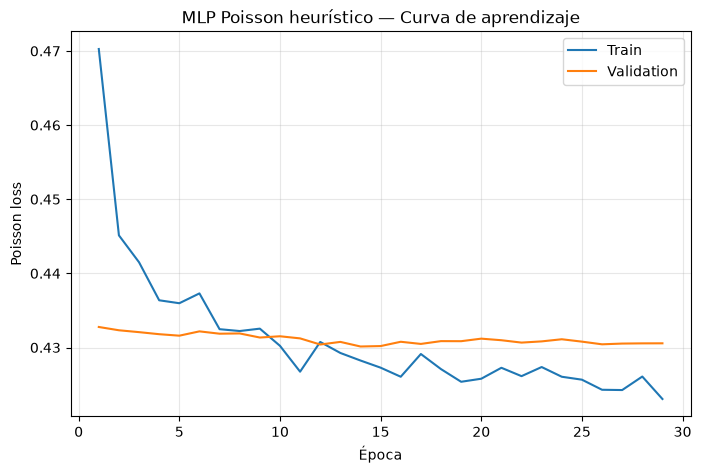

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_freq_df.index + 1,
    history_freq_df["loss"],
    label="Train"
)

plt.plot(
    history_freq_df.index + 1,
    history_freq_df["val_loss"],
    label="Validation"
)

plt.xlabel("Época")
plt.ylabel("Poisson loss")
plt.title(
    "MLP Poisson heurístico — Curva de aprendizaje"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

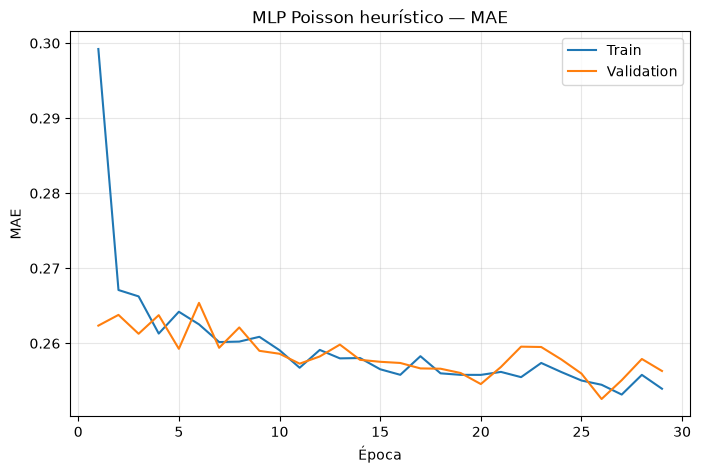

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_freq_df.index + 1,
    history_freq_df["mae"],
    label="Train"
)

plt.plot(
    history_freq_df.index + 1,
    history_freq_df["val_mae"],
    label="Validation"
)

plt.xlabel("Época")
plt.ylabel("MAE")
plt.title(
    "MLP Poisson heurístico — MAE"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 3.5 ¿Cuál fue la mejor época?

In [31]:
best_epoch_freq = (
    np.argmin(
        history_freq_heuristic.history["val_loss"]
    )
    + 1
)

best_val_loss_freq = np.min(
    history_freq_heuristic.history["val_loss"]
)

print(
    f"Mejor época: {best_epoch_freq}"
)

print(
    f"Mejor val_loss: "
    f"{best_val_loss_freq:.6f}"
)

Mejor época: 14
Mejor val_loss: 0.430136


### 3.6 Predicciones

In [32]:
pred_train_freq_mlp_heur = (
    mlp_freq_heuristic
    .predict(
        X_dl_train,
        verbose=0
    )
    .ravel()
)

pred_val_freq_mlp_heur = (
    mlp_freq_heuristic
    .predict(
        X_dl_val,
        verbose=0
    )
    .ravel()
)

pred_test_freq_mlp_heur = (
    mlp_freq_heuristic
    .predict(
        X_dl_test,
        verbose=0
    )
    .ravel()
)

La frecuencia predicha media en test es aproximadamente 0.1582 frente a una
frecuencia observada de 0.1575.

La diferencia relativa es cercana al 0.47%, por lo que el modelo presenta una
buena calibración agregada.

Sin embargo, esta coincidencia de medias no garantiza por sí sola que el modelo
ordene correctamente el riesgo individual entre pólizas; esa capacidad se
evaluará posteriormente mediante las métricas oracle.

In [33]:
# Veamos si softplus hizo que todas las predicciones son mayores que 0
print(
    "Predicción mínima test:",
    pred_test_freq_mlp_heur.min()
)

print(
    "Predicción máxima test:",
    pred_test_freq_mlp_heur.max()
)

print(
    "Predicción media test:",
    pred_test_freq_mlp_heur.mean()
)

print(
    "Frecuencia observada test:",
    y_freq_test.mean()
)

print(
    "Diferencia Relativa",
    (pred_test_freq_mlp_heur.mean()-y_freq_test.mean())/y_freq_test.mean()

)

Predicción mínima test: 0.041531418
Predicción máxima test: 0.6190025
Predicción media test: 0.15824385
Frecuencia observada test: 0.1575
Diferencia Relativa 0.004722864


### 3.7 Train, validation y test

Los resultados muestran un deterioro progresivo al pasar de entrenamiento a
validación y posteriormente a test:

$$
\text{train} < \text{validation} < \text{test}.
$$

La diferencia entre los tres conjuntos es moderada y no sugiere un problema
grave de sobreajuste.

La Poisson deviance aumenta aproximadamente de 0.566 en train a 0.583 en
validation y 0.593 en test, mientras que MAE y RMSE presentan un patrón similar.

Por tanto, la red generaliza razonablemente bien. El principal límite del modelo
no parece ser un sobreajuste severo, sino la precisión con la que consigue
recuperar la función de frecuencia subyacente.

In [34]:
freq_train_metrics_heur = regression_metrics(
    y_freq_train,
    pred_train_freq_mlp_heur
)

freq_val_metrics_heur = regression_metrics(
    y_freq_val,
    pred_val_freq_mlp_heur
)

freq_test_metrics_heur = regression_metrics(
    y_freq_test,
    pred_test_freq_mlp_heur
)

pd.DataFrame(
    [
        freq_train_metrics_heur,
        freq_val_metrics_heur,
        freq_test_metrics_heur
    ],
    index=[
        "Train",
        "Validation",
        "Test"
    ]
)

,MAE,RMSE
Train,0.256119,0.388202
Validation,0.257797,0.390565
Test,0.260476,0.392272


In [35]:
freq_train_deviance_heur = (
    mean_poisson_deviance(
        y_freq_train,
        pred_train_freq_mlp_heur
    )
)

freq_val_deviance_heur = (
    mean_poisson_deviance(
        y_freq_val,
        pred_val_freq_mlp_heur
    )
)

freq_test_deviance_heur = (
    mean_poisson_deviance(
        y_freq_test,
        pred_test_freq_mlp_heur
    )
)

pd.DataFrame({
    "Poisson_deviance": [
        freq_train_deviance_heur,
        freq_val_deviance_heur,
        freq_test_deviance_heur
    ]
}, index=[
    "Train",
    "Validation",
    "Test"
])

,Poisson_deviance
Train,0.565813
Validation,0.582996
Test,0.592861


### 3.8 Oracle

La evaluación contra la frecuencia verdadera muestra que la MLP heurística
recupera una parte importante de la estructura del riesgo.

El modelo obtiene un MAE oracle cercano a 0.0242, un RMSE de 0.0336 y una
correlación aproximada de 0.915.

Estos resultados mejoran los obtenidos por Random Forest en la recuperación de
la función verdadera y se acercan a los observados para XGBoost, aunque el GLM
Poisson continúa mostrando una ventaja clara.

In [36]:
freq_oracle_metrics_heur = regression_metrics(
    lambda_true_test,
    pred_test_freq_mlp_heur
)

freq_oracle_corr_heur = np.corrcoef(
    lambda_true_test,
    pred_test_freq_mlp_heur
)[0, 1]

print(
    f"Oracle MAE: "
    f"{freq_oracle_metrics_heur['MAE']:.6f}"
)

print(
    f"Oracle RMSE: "
    f"{freq_oracle_metrics_heur['RMSE']:.6f}"
)

print(
    f"Oracle correlation: "
    f"{freq_oracle_corr_heur:.4f}"
)

Oracle MAE: 0.024206
Oracle RMSE: 0.033638
Oracle correlation: 0.9149


### 3.9 Bayesian Optimization

La arquitectura heurística proporciona un punto de partida razonable para la
red neuronal, pero sus decisiones no se basan directamente en el desempeño
observado del modelo.

Por ejemplo, la heurística determinó:

- 2 capas ocultas;
- arquitectura 28 → 14;
- dropout de 0.15 y 0.1275;
- regularización L2 de 9e-5;
- learning rate fijo de 1e-3.

Estas decisiones están sustentadas por reglas predefinidas relacionadas con
el tamaño del dataset y el número de variables, pero no sabemos si constituyen
la mejor configuración para el problema actual.

Por ello se utilizará optimización bayesiana para explorar diferentes
combinaciones de hiperparámetros utilizando exclusivamente el conjunto de
validación.

El conjunto de test permanecerá completamente aislado durante todo el proceso
de selección.

#### Hiperparámetros

Los parámetros de una red neuronal pueden dividirse en dos grupos.

**Parámetros aprendidos durante el entrenamiento**

Son los pesos y sesgos de la red:

$$
W,\;b
$$

y son actualizados automáticamente mediante backpropagation y descenso por
gradiente.

**Hiperparámetros**

Son decisiones externas al entrenamiento, por ejemplo:

- número de capas;
- número de neuronas;
- learning rate;
- dropout;
- penalización L2;
- batch size.

Estos valores no son aprendidos directamente mediante backpropagation y deben
ser seleccionados mediante algún procedimiento adicional.


#### Objetivo de la búsqueda

Cada conjunto de hiperparámetros define una arquitectura diferente.

Sea:

$$
h = (L,n_1,r,d,\lambda,\eta)
$$

el conjunto de hiperparámetros de una red.

El objetivo de la optimización es encontrar:

$$
h^* =
\arg\min_h L_{\mathrm{validation}}(h)
$$

donde $L_{\mathrm{validation}}$ corresponde a la pérdida Poisson calculada
sobre el conjunto de validación.

El conjunto de test no participa en esta optimización.

#### ¿Por qué optimización bayesiana?

Una búsqueda aleatoria selecciona cada combinación de hiperparámetros
independientemente de los resultados anteriores.

La optimización bayesiana utiliza los experimentos ya realizados para construir
un modelo probabilístico aproximado de la relación:

$$
h \longrightarrow L_{\mathrm{validation}}.
$$

Después utiliza este modelo para seleccionar qué combinación evaluar a
continuación.

La búsqueda intenta equilibrar dos comportamientos:

- **Exploitation:** probar regiones que parecen prometedoras.
- **Exploration:** investigar regiones sobre las cuales existe mayor
  incertidumbre.

Por ello puede encontrar buenas configuraciones utilizando menos evaluaciones
que una exploración exhaustiva del espacio.

In [37]:
import keras_tuner as kt
import tensorboard

print("TensorFlow:", tf.__version__)
print("Keras Tuner:", kt.__version__)
print("TensorBoard:", tensorboard.__version__)

TensorFlow: 2.21.0
Keras Tuner: 1.4.8
TensorBoard: 2.21.0


#### 3.9.1 Definición del espacio de búsqueda

In [38]:
SEARCH_SPACE = {
    "n_layers": "1 a 4",
    "first_units": [16, 32, 64, 128],
    "reduction": [0.5, 0.75, 1.0],
    "dropout": "0.00 a 0.40",
    "l2": "1e-6 a 1e-2",
    "learning_rate": "1e-4 a 3e-3"
}

SEARCH_SPACE

{'n_layers': '1 a 4',
 'first_units': [16, 32, 64, 128],
 'reduction': [0.5, 0.75, 1.0],
 'dropout': '0.00 a 0.40',
 'l2': '1e-6 a 1e-2',
 'learning_rate': '1e-4 a 3e-3'}

#### 3.9.2 Constructor de modelos para Bayesian Optimization

**Escala logarítmica**

Algunos hiperparámetros no deben explorarse de forma uniforme en escala lineal.

Por ejemplo, para L2 pueden ser razonables valores como:

$$
10^{-6},10^{-5},10^{-4},10^{-3},10^{-2}.
$$

La diferencia relevante está en los órdenes de magnitud.

Por este motivo `sampling="log"` permite explorar de manera más apropiada
hiperparámetros como:

- regularización L2;
- learning rate.

In [39]:
def build_poisson_mlp_tuned(hp):
    """
    Construye una MLP para frecuencia Poisson cuyos hiperparámetros
    son seleccionados por Keras Tuner.

    La red estima:

        lambda_hat(X) = E[N | X]

    por lo que utiliza una salida Softplus para garantizar
    predicciones estrictamente positivas.
    """

    # ---------------------------------------------------------
    # 1. Número de capas ocultas
    # ---------------------------------------------------------
    n_layers = hp.Int(
        name="n_layers",
        min_value=1,
        max_value=4,
        step=1
    )

    # ---------------------------------------------------------
    # 2. Número de neuronas de la primera capa
    # ---------------------------------------------------------
    first_units = hp.Choice(
        name="first_units",
        values=[16, 32, 64, 128]
    )

    # ---------------------------------------------------------
    # 3. Factor de reducción entre capas
    #
    # 0.50 → embudo fuerte
    # 0.75 → embudo moderado
    # 1.00 → ancho constante
    # ---------------------------------------------------------
    reduction = hp.Choice(
        name="reduction",
        values=[0.5, 0.75, 1.0]
    )

    # ---------------------------------------------------------
    # 4. Dropout
    # ---------------------------------------------------------
    dropout = hp.Float(
        name="dropout",
        min_value=0.0,
        max_value=0.40,
        step=0.05
    )

    # ---------------------------------------------------------
    # 5. Penalización L2
    #
    # sampling="log" es importante porque queremos explorar
    # órdenes de magnitud:
    #
    # 1e-6, ..., 1e-4, ..., 1e-2
    # ---------------------------------------------------------
    l2_value = hp.Float(
        name="l2",
        min_value=1e-6,
        max_value=1e-2,
        sampling="log"
    )

    # ---------------------------------------------------------
    # 6. Learning rate
    #
    # También se busca en escala logarítmica.
    # ---------------------------------------------------------
    learning_rate = hp.Float(
        name="learning_rate",
        min_value=1e-4,
        max_value=3e-3,
        sampling="log"
    )

    # =========================================================
    # CONSTRUCCIÓN DE LA RED
    # =========================================================

    model = keras.Sequential(
        name="poisson_mlp_bayesian"
    )

    model.add(
        keras.layers.Input(
            shape=(n0,)
        )
    )

    units = first_units

    for layer_idx in range(n_layers):

        # Evitamos capas excesivamente pequeñas.
        units_current = max(
            8,
            int(round(units))
        )

        model.add(
            keras.layers.Dense(
                units=units_current,
                activation="relu",

                kernel_regularizer=(
                    keras.regularizers.l2(
                        l2_value
                    )
                )
            )
        )

        if dropout > 0:

            model.add(
                keras.layers.Dropout(
                    rate=dropout
                )
            )

        # Ancho de la siguiente capa
        units *= reduction

    # ---------------------------------------------------------
    # Salida positiva
    #
    # λ_hat > 0
    # ---------------------------------------------------------
    model.add(
        keras.layers.Dense(
            units=1,
            activation="softplus"
        )
    )

    # =========================================================
    # COMPILACIÓN
    # =========================================================

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=keras.losses.Poisson(),

        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

#### 3.9.2 Crear el Bayesian Optimizer

In [40]:
keras.backend.clear_session()
set_reproducibility(SEED)



In [41]:
import shutil

TUNER_DIR = Path(
    "../results/tuning/frequency_bayesian"
)

# Elimina resultados.
if TUNER_DIR.exists():
    shutil.rmtree(TUNER_DIR)

In [42]:
tuner_freq = kt.BayesianOptimization(
    hypermodel=build_poisson_mlp_tuned,

    # Métrica que Bayes intentará minimizar.
    objective=kt.Objective(
        "val_loss",
        direction="min"
    ),

    # Número máximo de arquitecturas evaluadas.
    max_trials=20,

    # Una ejecución por configuración.
    executions_per_trial=1,

    seed=SEED,

    directory=str(TUNER_DIR),

    project_name="poisson_mlp",

    overwrite=True
)

#### 3.9.3 Inspeccionar espacio antes de entrenar

In [43]:
set_reproducibility(SEED)

In [44]:
tuner_freq.search_space_summary()

Search space summary
Default search space size: 6
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
first_units (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64, 128], 'ordered': True}
reduction (Choice)
{'default': 0.5, 'conditions': [], 'values': [0.5, 0.75, 1.0], 'ordered': True}
dropout (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.4, 'step': 0.05, 'sampling': 'linear'}
l2 (Float)
{'default': 1e-06, 'conditions': [], 'min_value': 1e-06, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.003, 'step': None, 'sampling': 'log'}


#### 3.9.4 Early Stopping durante la búsqueda

In [45]:
tuning_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=0
)

#### 3.9.5 Ejecutar la búsqueda

**Independencia del conjunto de test**

Durante la optimización bayesiana únicamente se utilizarán:

- `X_dl_train`, `y_freq_train` para actualizar los pesos;
- `X_dl_val`, `y_freq_val` para seleccionar hiperparámetros.

Las 2,000 observaciones del conjunto de test no se utilizarán para:

- seleccionar arquitectura;
- seleccionar learning rate;
- seleccionar regularización;
- aplicar early stopping.

Esto evita adaptar indirectamente el modelo al conjunto de evaluación final.

In [46]:
set_reproducibility(SEED)

start = time.perf_counter()

tuner_freq.search(
    X_dl_train,
    y_freq_train,

    validation_data=(
        X_dl_val,
        y_freq_val
    ),

    epochs=120,

    batch_size=32,

    callbacks=[
        tuning_early_stopping
    ],

    verbose=1
)

freq_bayesian_search_time = (
    time.perf_counter()
    - start
)

print(
    "\nTiempo total de Bayesian Optimization: "
    f"{freq_bayesian_search_time:.2f} segundos"
)

Trial 20 Complete [00h 00m 13s]
val_loss: 0.4275904893875122

Best val_loss So Far: 0.426492303609848
Total elapsed time: 00h 05m 37s

Tiempo total de Bayesian Optimization: 337.16 segundos


### 3.9.6 Revisar los mejores trials

In [47]:
tuner_freq.results_summary(
    num_trials=10
)

Results summary
Results in ..\results\tuning\frequency_bayesian\poisson_mlp
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 06 summary
Hyperparameters:
n_layers: 4
first_units: 16
reduction: 0.5
dropout: 0.2
l2: 3.7921212101221703e-06
learning_rate: 0.0005406084430304633
Score: 0.426492303609848

Trial 05 summary
Hyperparameters:
n_layers: 1
first_units: 32
reduction: 1.0
dropout: 0.2
l2: 3.0354743289178576e-05
learning_rate: 0.001514922084236242
Score: 0.4268675148487091

Trial 18 summary
Hyperparameters:
n_layers: 1
first_units: 32
reduction: 1.0
dropout: 0.35000000000000003
l2: 1e-06
learning_rate: 0.0009558058498015099
Score: 0.42732468247413635

Trial 19 summary
Hyperparameters:
n_layers: 4
first_units: 32
reduction: 0.5
dropout: 0.30000000000000004
l2: 1e-06
learning_rate: 0.0023349850820359153
Score: 0.4275904893875122

Trial 09 summary
Hyperparameters:
n_layers: 2
first_units: 16
reduction: 0.75
dropout: 0.15000000000000002
l2: 3.8254014699751585e-06
l

In [48]:
best_hp_freq = (
    tuner_freq
    .get_best_hyperparameters(
        num_trials=1
    )[0]
)

In [49]:
print(
    "Mejores hiperparámetros "
    "encontrados:\n"
)

for name, value in (
    best_hp_freq.values.items()
):

    print(
        f"{name:<20}: {value}"
    )

Mejores hiperparámetros encontrados:

n_layers            : 4
first_units         : 16
reduction           : 0.5
dropout             : 0.2
l2                  : 3.7921212101221703e-06
learning_rate       : 0.0005406084430304633


### Resultado de la optimización bayesiana

La optimización bayesiana seleccionó una arquitectura de cuatro capas ocultas:

$$
16 \rightarrow 8 \rightarrow 8 \rightarrow 8.
$$

La configuración elegida utiliza:

- `dropout = 0.20`;
- penalización L2 aproximada de $3.8\times10^{-6}$;
- `learning_rate` ≈ $5.4\times10^{-4}$.

En comparación con la arquitectura heurística $28 \rightarrow 14$, el modelo
seleccionado es más profundo pero utiliza capas considerablemente más estrechas
y una penalización L2 mucho menor.

La mejor pérdida de validación disminuye de aproximadamente 0.4301 en el modelo
heurístico a 0.4265 mediante optimización bayesiana, lo que representa una
mejora cercana al 0.85%.

La mejora debe analizarse conjuntamente con el costo computacional. El
entrenamiento del modelo heurístico requirió alrededor de 9 segundos, mientras
que la búsqueda de 20 configuraciones mediante optimización bayesiana necesitó
aproximadamente 337 segundos.

Por tanto, la búsqueda requiere alrededor de 36 veces más tiempo de cómputo para
obtener una mejora relativamente pequeña en la pérdida de validación.

### 3.10 Validar configuración ganadora

#### 3.10.1 Extraer arquitectura

In [50]:
best_n_layers = best_hp_freq.get(
    "n_layers"
)

best_first_units = best_hp_freq.get(
    "first_units"
)

best_reduction = best_hp_freq.get(
    "reduction"
)

best_dropout = best_hp_freq.get(
    "dropout"
)

best_l2 = best_hp_freq.get(
    "l2"
)

best_learning_rate = best_hp_freq.get(
    "learning_rate"
)

In [51]:
best_architecture = []

units = best_first_units

for _ in range(best_n_layers):

    current_units = max(
        8,
        int(round(units))
    )

    best_architecture.append(
        current_units
    )

    units *= best_reduction

print(
    "Arquitectura:",
    best_architecture
)

Arquitectura: [16, 8, 8, 8]


#### 3.10.2 Constructor

In [52]:
def build_fixed_poisson_mlp(
    n0,
    architecture,
    dropout,
    l2_value,
    learning_rate
):
    """
    Construye una MLP Poisson con hiperparámetros
    previamente seleccionados.
    """

    model = keras.Sequential(
        name="poisson_mlp_bayesian_final"
    )

    model.add(
        keras.layers.Input(
            shape=(n0,)
        )
    )

    for units in architecture:

        model.add(
            keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=(
                    keras.regularizers.l2(
                        l2_value
                    )
                )
            )
        )

        if dropout > 0:
            model.add(
                keras.layers.Dropout(
                    dropout
                )
            )

    model.add(
        keras.layers.Dense(
            1,
            activation="softplus"
        )
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=keras.losses.Poisson(),

        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

#### 3.10.3 Ejecuciones independientes

**Estabilidad de la configuración seleccionada**

La arquitectura seleccionada mediante optimización bayesiana se entrenó
posteriormente utilizando tres semillas distintas para estudiar su sensibilidad
a la inicialización aleatoria.

La mejor pérdida de validación varió aproximadamente entre 0.4274 y 0.4309, con
una desviación estándar cercana a 0.0018.

Las mejores épocas también mostraron cierta variabilidad, situándose entre 21 y
51 épocas.

Estos resultados muestran que, aunque la arquitectura y los hiperparámetros se
mantienen fijos, el entrenamiento de una red neuronal conserva variabilidad
debida a la inicialización de pesos, Dropout y dinámica de mini-batches.

Por esta razón, la configuración no se evalúa a partir de una única ejecución
afortunada. Las múltiples semillas permiten estimar la estabilidad del proceso y
utilizar una medida robusta del número de épocas para el refit final.

In [53]:
validation_runs = []

VALIDATION_SEEDS = [
    42,
    123,
    2026
]

In [54]:
for seed in VALIDATION_SEEDS:

    keras.backend.clear_session()

    set_reproducibility(seed)

    model_run = build_fixed_poisson_mlp(
        n0=n0,
        architecture=best_architecture,
        dropout=best_dropout,
        l2_value=best_l2,
        learning_rate=best_learning_rate
    )

    early_stopping = (
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=0
        )
    )

    start = time.perf_counter()

    history_run = model_run.fit(
        X_dl_train,
        y_freq_train,

        validation_data=(
            X_dl_val,
            y_freq_val
        ),

        epochs=200,
        batch_size=32,

        callbacks=[
            early_stopping
        ],

        verbose=0
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    val_losses = (
        history_run.history[
            "val_loss"
        ]
    )

    best_epoch = (
        np.argmin(val_losses)
        + 1
    )

    best_loss = np.min(
        val_losses
    )

    validation_runs.append({
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_loss": best_loss,
        "epochs_run": len(val_losses),
        "time_seconds": elapsed
    })

In [55]:
bayesian_validation_runs = (
    pd.DataFrame(
        validation_runs
    )
)

bayesian_validation_runs

,seed,best_epoch,best_val_loss,epochs_run,time_seconds
0,42,51,0.427359,53,17.502939
1,123,21,0.430866,36,12.613552
2,2026,34,0.429259,48,15.891489


In [56]:
bayesian_validation_runs[
    [
        "best_epoch",
        "best_val_loss"
    ]
].agg(
    ["mean", "std", "min", "max"]
)

,best_epoch,best_val_loss
mean,35.333333,0.429162
std,15.044379,0.001755
min,21.000000,0.427359
max,51.000000,0.430866


#### 3.10.4 Definir número de épocas para el refit final

La mediana de las mejores épocas observadas es 34, por lo que este valor se
utilizará como número de épocas para el entrenamiento final.

La mediana se utiliza en lugar del mejor resultado individual para reducir la
dependencia de una inicialización específica.

In [57]:
final_epochs_freq = int(
    np.median(
        bayesian_validation_runs[
            "best_epoch"
        ]
    )
)

print(
    "Épocas para refit final:",
    final_epochs_freq
)

Épocas para refit final: 34


### 3.11 Refit final de la MLP de frecuencia

Una vez seleccionados la arquitectura, los hiperparámetros y el número de
épocas utilizando únicamente train y validation, ambas muestras pueden
reintegrarse.

El modelo final se entrena utilizando las 8,000 pólizas del train maestro.

El conjunto de test externo permanece sin utilizar durante todo el proceso de
selección y se empleará únicamente para la evaluación final.

Como validation deja de ser necesaria, el modelo final se entrena durante un
número fijo de épocas previamente seleccionado a partir de las ejecuciones con
múltiples semillas.

#### 3.11.1 Reajustar el preprocessing

In [58]:
preprocessor_dl_final = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            CATEGORICAL_FEATURES
        )
    ]
)

In [59]:
X_freq_train_final = (
    preprocessor_dl_final
    .fit_transform(
        df_train[FEATURES]
    )
    .astype(np.float32)
)

X_freq_test_final = (
    preprocessor_dl_final
    .transform(
        df_test[FEATURES]
    )
    .astype(np.float32)
)

y_freq_train_final = (
    df_train["numero_siniestros"]
    .to_numpy(dtype=np.float32)
)

y_freq_test_final = (
    df_test["numero_siniestros"]
    .to_numpy(dtype=np.float32)
)

lambda_true_test = (
    df_test["lambda_real"]
    .to_numpy(dtype=np.float32)
)

In [60]:
print(
    "Train final:",
    X_freq_train_final.shape
)

print(
    "Test final:",
    X_freq_test_final.shape
)

assert (
    X_freq_train_final.shape[1]
    ==
    X_freq_test_final.shape[1]
)

Train final: (8000, 14)
Test final: (2000, 14)


#### 3.11.2 Arquitectura final

La arquitectura utilizada en el modelo final corresponde exactamente a la
configuración seleccionada mediante optimización bayesiana.

En esta etapa no se realizan nuevas decisiones sobre profundidad, ancho,
Dropout, regularización L2 o learning rate.

Esto permite mantener separado el proceso de selección del proceso de
evaluación final.

In [61]:
keras.backend.clear_session()

set_reproducibility(SEED)

mlp_freq_final = build_fixed_poisson_mlp(
    n0=X_freq_train_final.shape[1],
    architecture=best_architecture,
    dropout=best_dropout,
    l2_value=best_l2,
    learning_rate=best_learning_rate
)

mlp_freq_final.summary()

Model: "poisson_mlp_bayesian_final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529 (2.07 KB)

 Trainable params: 529 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
freq_final_n_params = (
    mlp_freq_final.count_params()
)

print(
    f"Parámetros entrenables: "
    f"{freq_final_n_params:,}"
)

Parámetros entrenables: 529


#### 3.11.3 Entrenamiento final

El modelo final se entrenó durante 34 épocas, valor obtenido previamente como
la mediana de las mejores épocas observadas en varias ejecuciones sobre
train/validation.

Este procedimiento proporciona una regla de refit definida antes de observar
el conjunto de test.

Sin embargo, debe tenerse en cuenta que el número óptimo de épocas estimado con
6,400 observaciones no necesariamente coincide con el óptimo al entrenar sobre
las 8,000 observaciones. Por esta razón, el resultado obtenido se conserva como
parte del protocolo experimental y no se realizan ajustes retrospectivos
utilizando las métricas de test.

In [63]:
set_reproducibility(SEED)

start = time.perf_counter()

history_freq_final = mlp_freq_final.fit(
    X_freq_train_final,
    y_freq_train_final,

    epochs=final_epochs_freq,

    batch_size=32,

    shuffle=True,

    verbose=0
)

freq_final_train_time = (
    time.perf_counter()
    - start
)

print(
    f"Tiempo entrenamiento final: "
    f"{freq_final_train_time:.2f} segundos"
)

print(
    f"Épocas: {final_epochs_freq}"
)

Tiempo entrenamiento final: 12.27 segundos
Épocas: 34


#### 3.11.4 Predicciones finales

Las predicciones finales son estrictamente positivas, como corresponde a una
frecuencia esperada.

La frecuencia media predicha es aproximadamente 0.168 frente a una frecuencia
observada de 0.1575, lo que representa una sobreestimación agregada cercana al
6.6%.

Además, las predicciones se concentran en un intervalo relativamente estrecho,
aproximadamente entre 0.074 y 0.262. Esta compresión del rango sugiere que el
modelo puede estar distinguiendo de forma limitada entre pólizas de bajo y alto
riesgo, aspecto que posteriormente se confirma mediante la comparación oracle.

In [64]:
pred_train_freq_mlp_final = (
    mlp_freq_final
    .predict(
        X_freq_train_final,
        verbose=0
    )
    .ravel()
)

pred_test_freq_mlp_final = (
    mlp_freq_final
    .predict(
        X_freq_test_final,
        verbose=0
    )
    .ravel()
)

In [65]:
print(
    f"Predicción mínima test: "
    f"{pred_test_freq_mlp_final.min():.6f}"
)

print(
    f"Predicción máxima test: "
    f"{pred_test_freq_mlp_final.max():.6f}"
)

print(
    f"Predicción media test: "
    f"{pred_test_freq_mlp_final.mean():.6f}"
)

print(
    f"Frecuencia observada test: "
    f"{y_freq_test_final.mean():.6f}"
)

Predicción mínima test: 0.073907
Predicción máxima test: 0.261748
Predicción media test: 0.167968
Frecuencia observada test: 0.157500


#### 3.11.5 Métricas

En las métricas observables, el modelo bayesiano final no muestra una mejora
generalizada frente a la arquitectura heurística.

El MAE aumenta aproximadamente un 3.9%, mientras que el RMSE y la Poisson
deviance presentan mejoras muy pequeñas, inferiores al 0.2%.

Por tanto, desde el punto de vista de la realización observada de los siniestros,
ambas estrategias muestran desempeños muy similares y no existe evidencia de
una ganancia predictiva importante asociada al proceso adicional de
optimización.

In [66]:
freq_final_train_metrics = regression_metrics(
    y_freq_train_final,
    pred_train_freq_mlp_final
)

freq_final_test_metrics = regression_metrics(
    y_freq_test_final,
    pred_test_freq_mlp_final
)

pd.DataFrame(
    [
        freq_final_train_metrics,
        freq_final_test_metrics
    ],
    index=[
        "Train",
        "Test"
    ]
)

,MAE,RMSE
Train,0.268281,0.391931
Test,0.270559,0.392080


In [67]:
freq_final_train_deviance = (
    mean_poisson_deviance(
        y_freq_train_final,
        pred_train_freq_mlp_final
    )
)

freq_final_test_deviance = (
    mean_poisson_deviance(
        y_freq_test_final,
        pred_test_freq_mlp_final
    )
)

pd.DataFrame(
    {
        "Poisson_deviance": [
            freq_final_train_deviance,
            freq_final_test_deviance
        ]
    },
    index=[
        "Train",
        "Test"
    ]
)

,Poisson_deviance
Train,0.580706
Test,0.592096


#### 3.11.6 Oracle

La evaluación oracle revela una diferencia mucho más marcada que las métricas
basadas en los conteos observados.

El RMSE respecto a la frecuencia verdadera aumenta aproximadamente un 38% y la
correlación disminuye de cerca de 0.915 a 0.838.

Este comportamiento indica que el modelo final reproduce razonablemente la
realización observada de los conteos, pero recupera peor la heterogeneidad
subyacente del riesgo.

La menor dispersión de las predicciones es consistente con esta pérdida de
capacidad para diferenciar correctamente entre pólizas de bajo y alto riesgo.

In [68]:
freq_final_oracle_metrics = (
    regression_metrics(
        lambda_true_test,
        pred_test_freq_mlp_final
    )
)

freq_final_oracle_corr = np.corrcoef(
    lambda_true_test,
    pred_test_freq_mlp_final
)[0, 1]

print(
    f"Oracle MAE: "
    f"{freq_final_oracle_metrics['MAE']:.6f}"
)

print(
    f"Oracle RMSE: "
    f"{freq_final_oracle_metrics['RMSE']:.6f}"
)

print(
    f"Oracle correlation: "
    f"{freq_final_oracle_corr:.4f}"
)

Oracle MAE: 0.029398
Oracle RMSE: 0.046499
Oracle correlation: 0.8380


#### 3.11.7 Comparación heurística vs optimización bayesiana

La optimización bayesiana consiguió mejorar el criterio utilizado durante la
selección en validation, pero dicha mejora no se tradujo en una recuperación
superior de la función verdadera de frecuencia.

El resultado ilustra una distinción central del experimento:

$$
\text{mejor desempeño sobre datos observados}
\not\Rightarrow
\text{mejor recuperación de la esperanza condicional}.
$$

Dado que los conteos individuales contienen ruido Poisson, dos modelos pueden
obtener métricas observables similares y, sin embargo, diferir
considerablemente en su capacidad para aproximar $\lambda(X)$.

Por consistencia metodológica, el modelo final se conserva sin realizar ajustes
posteriores basados en test u oracle.

In [69]:
frequency_dl_comparison = pd.DataFrame({
    "Modelo": [
        "MLP heurístico",
        "MLP bayesiano final"
    ],

    "MAE test": [
        freq_test_metrics_heur["MAE"],
        freq_final_test_metrics["MAE"]
    ],

    "RMSE test": [
        freq_test_metrics_heur["RMSE"],
        freq_final_test_metrics["RMSE"]
    ],

    "Poisson deviance": [
        freq_test_deviance_heur,
        freq_final_test_deviance
    ],

    "Oracle MAE": [
        freq_oracle_metrics_heur["MAE"],
        freq_final_oracle_metrics["MAE"]
    ],

    "Oracle RMSE": [
        freq_oracle_metrics_heur["RMSE"],
        freq_final_oracle_metrics["RMSE"]
    ],

    "Oracle correlation": [
        freq_oracle_corr_heur,
        freq_final_oracle_corr
    ]
})

frequency_dl_comparison

,Modelo,MAE test,RMSE test,Poisson deviance,Oracle MAE,Oracle RMSE,Oracle correlation
0,MLP heurístico,0.260476,0.392272,0.592861,0.024206,0.033638,0.914875
1,MLP bayesiano final,0.270559,0.392080,0.592096,0.029398,0.046499,0.837959


### Conclusión de frecuencia

En frecuencia, la complejidad adicional del tuning bayesiano no produjo una
mejora clara frente a una arquitectura heurística simple.

Hasta este punto, el GLM Poisson continúa ofreciendo la recuperación más precisa
del DGP, mientras que XGBoost y la MLP heurística muestran resultados
competitivos sin superar al modelo estadístico correctamente especificado.

## Severidad

### 4.1 Preparación de los datos

La severidad se modela a nivel siniestro, por lo que cada fila representa un
claim individual.

Para evitar leakage, los siniestros no se dividen aleatoriamente. Cada claim
hereda el split de la póliza a la que pertenece.

Esto garantiza que todos los siniestros asociados a una misma póliza se
encuentren exclusivamente en train, validation o test.

In [70]:
CLAIMS_PATH = Path(
    "../data/raw/synthetic_insurance_claims.csv"
)

claims = pd.read_csv(CLAIMS_PATH)

claims = claims.merge(
    split_df,
    on="policy_id",
    how="left",
    validate="many_to_one"
)

claims = claims.merge(
    dl_split_df,
    on="policy_id",
    how="left",
    validate="many_to_one"
)

In [71]:
assert claims["split"].notna().all()

assert (
    claims.loc[
        claims["split"] == "train",
        "dl_split"
    ]
    .notna()
    .all()
)

In [72]:
claims_dl_train = claims[
    (claims["split"] == "train")
    &
    (claims["dl_split"] == "train")
].copy()

claims_dl_val = claims[
    (claims["split"] == "train")
    &
    (claims["dl_split"] == "validation")
].copy()

claims_test = claims[
    claims["split"] == "test"
].copy()

print(
    f"Claims train DL:      {len(claims_dl_train):,}"
)

print(
    f"Claims validation DL: {len(claims_dl_val):,}"
)

print(
    f"Claims test:          {len(claims_test):,}"
)

Claims train DL:      993
Claims validation DL: 246
Claims test:          315


In [73]:
train_policies_sev = set(
    claims_dl_train["policy_id"]
)

val_policies_sev = set(
    claims_dl_val["policy_id"]
)

test_policies_sev = set(
    claims_test["policy_id"]
)

assert train_policies_sev.isdisjoint(
    val_policies_sev
)

assert train_policies_sev.isdisjoint(
    test_policies_sev
)

assert val_policies_sev.isdisjoint(
    test_policies_sev
)

print("No existe solapamiento entre pólizas.")

No existe solapamiento entre pólizas.


## 4.2 Preprocesamiento

In [74]:
preprocessor_sev = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            CATEGORICAL_FEATURES
        )
    ]
)

In [75]:
X_sev_train = (
    preprocessor_sev
    .fit_transform(
        claims_dl_train[FEATURES]
    )
    .astype(np.float32)
)

X_sev_val = (
    preprocessor_sev
    .transform(
        claims_dl_val[FEATURES]
    )
    .astype(np.float32)
)

X_sev_test = (
    preprocessor_sev
    .transform(
        claims_test[FEATURES]
    )
    .astype(np.float32)
)

print(
    "Train:",
    X_sev_train.shape
)

print(
    "Validation:",
    X_sev_val.shape
)

print(
    "Test:",
    X_sev_test.shape
)

Train: (993, 14)
Validation: (246, 14)
Test: (315, 14)


### 4.3 Target y normalización

La severidad se expresa originalmente en una escala monetaria del orden de
miles de unidades.

Para mejorar la estabilidad numérica del entrenamiento se divide el target por
la severidad media del conjunto de train.

Esta transformación no modifica la interpretación relativa del problema y las
predicciones se transformarán nuevamente a la escala original antes de calcular
las métricas finales.

In [76]:
y_sev_train = (
    claims_dl_train["severidad"]
    .to_numpy(dtype=np.float32)
)

y_sev_val = (
    claims_dl_val["severidad"]
    .to_numpy(dtype=np.float32)
)

y_sev_test = (
    claims_test["severidad"]
    .to_numpy(dtype=np.float32)
)

severity_true_test = (
    claims_test[
        "severidad_esperada_real"
    ]
    .to_numpy(dtype=np.float32)
)

SEVERITY_SCALE = (
    y_sev_train.mean()
)

y_sev_train_scaled = (
    y_sev_train
    / SEVERITY_SCALE
)

y_sev_val_scaled = (
    y_sev_val
    / SEVERITY_SCALE
)

y_sev_test_scaled = (
    y_sev_test
    / SEVERITY_SCALE
)

print(
    f"Escala de severidad: "
    f"{SEVERITY_SCALE:,.2f}"
)

Escala de severidad: 12,636.49


### 4.4 Pérdida Gamma

Para mantener la comparación con el GLM Gamma, vamos a entrenar la red utilizando una pérdida basada en Gamma deviance.

La deviance individual es:

$$
D(y,\mu)
=
2\left[
\log\left(\frac{\mu}{y}\right)
+
\frac{y}{\mu}
-1
\right].
$$

In [77]:
def gamma_deviance_loss(
    y_true,
    y_pred
):
    """
    Gamma deviance por observación.

    Requiere:
        y_true > 0
        y_pred > 0
    """

    eps = keras.backend.epsilon()

    y_true = tf.maximum(
        tf.cast(
            y_true,
            tf.float32
        ),
        eps
    )

    y_pred = tf.maximum(
        tf.cast(
            y_pred,
            tf.float32
        ),
        eps
    )

    return 2.0 * (
        tf.math.log(
            y_pred / y_true
        )
        +
        y_true / y_pred
        - 1.0
    )

In [78]:
test_y = tf.constant(
    [1.0, 2.0, 3.0]
)

test_mu = tf.constant(
    [1.0, 2.0, 3.0]
)

gamma_deviance_loss(
    test_y,
    test_mu
).numpy()

array([0., 0., 0.], dtype=float32)

### 4.5 Arquitectura heurística de severidad

La arquitectura heurística mantiene dos capas ocultas de 28 y 14 neuronas,
debido a que la dimensionalidad de entrada continúa siendo de 14 variables.

Sin embargo, el tamaño de muestra disponible para severidad es
considerablemente menor que en frecuencia: solamente 993 siniestros forman
parte del conjunto de entrenamiento.

La heurística responde aumentando la regularización:

- el Dropout pasa aproximadamente a 0.25 y 0.21;
- la penalización L2 aumenta a $3\times10^{-4}$;
- la paciencia de Early Stopping aumenta a 20 épocas.

La red utiliza solamente alrededor del 8.5% del presupuesto máximo de parámetros,
por lo que la restricción principal no proviene del número de parámetros sino de
la necesidad de controlar el sobreajuste en una muestra relativamente pequeña.

In [79]:
d_sev = X_sev_train.shape[0]
n0_sev = X_sev_train.shape[1]

print("d severidad =", d_sev)
print("n0 severidad =", n0_sev)

d severidad = 993
n0 severidad = 14


In [80]:
diseno_sev = (
    disenar_red_embudo_regresion(
        d=d_sev,
        n0=n0_sev
    )
)

diseno_sev

DisenoRedRegresion(capas=[28, 14], P=841, rho=0.08469284994964753, l2=0.0003, dropouts=[0.24999999999999997, 0.21249999999999997], patience=20, min_delta=0.0001, max_epochs=400)

### 4.6 Constructor Gamma MLP

In [83]:
def build_gamma_mlp(
    n0,
    capas,
    l2_value,
    dropouts,
    learning_rate=1e-3
):
    """
    MLP para severidad positiva con
    Gamma deviance como función de pérdida.
    """

    model = keras.Sequential(
        name="gamma_mlp"
    )

    model.add(
        keras.layers.Input(
            shape=(n0,)
        )
    )

    for units, dr in zip(
        capas,
        dropouts
    ):

        model.add(
            keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=(
                    keras.regularizers.l2(
                        l2_value
                    )
                )
            )
        )

        model.add(
            keras.layers.Dropout(
                dr
            )
        )

    initial_output = np.log(
        np.exp(1.0) - 1.0
    )

    model.add(
        keras.layers.Dense(
            1,
            activation="softplus",
            bias_initializer=keras.initializers.Constant(
            initial_output
            )
        )
    )   

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=gamma_deviance_loss,

        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

### 4.7 Entrenamiento del MLP Gamma heurístico

El entrenamiento finalizó después de 40 épocas debido al criterio de
Early Stopping. La mejor pérdida de validación se obtuvo en la época 20,
por lo que los pesos correspondientes a dicha época fueron restaurados
automáticamente.

El tiempo de entrenamiento fue de aproximadamente 5 segundos, lo que refleja
el tamaño reducido tanto de la red como del conjunto de datos.

La diferencia entre la mejor época y la época de detención coincide con
`patience = 20`, confirmando que el mecanismo de Early Stopping funcionó
según lo esperado.

In [84]:
capas_sev = diseno_sev.capas
l2_sev = diseno_sev.l2
dropouts_sev = diseno_sev.dropouts
patience_sev = diseno_sev.patience
min_delta_sev = diseno_sev.min_delta
max_epochs_sev = diseno_sev.max_epochs

In [85]:
keras.backend.clear_session()
set_reproducibility(SEED)

mlp_sev_heuristic = build_gamma_mlp(
    n0=n0_sev,
    capas=capas_sev,
    l2_value=l2_sev,
    dropouts=dropouts_sev,
    learning_rate=1e-3
)

mlp_sev_heuristic.summary()

Model: "gamma_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 841 (3.29 KB)

 Trainable params: 841 (3.29 KB)

 Non-trainable params: 0 (0.00 B)

### 4.8 Early Stopping

In [86]:
callbacks_sev = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience_sev,
        min_delta=min_delta_sev,
        restore_best_weights=True,
        verbose=1
    )
]

In [87]:
set_reproducibility(SEED)

start = time.perf_counter()

history_sev_heuristic = mlp_sev_heuristic.fit(
    X_sev_train,
    y_sev_train_scaled,

    validation_data=(
        X_sev_val,
        y_sev_val_scaled
    ),

    epochs=max_epochs_sev,
    batch_size=32,

    callbacks=callbacks_sev,

    verbose=0
)

sev_heuristic_train_time = (
    time.perf_counter()
    - start
)

print(
    f"Tiempo de entrenamiento: "
    f"{sev_heuristic_train_time:.2f} segundos"
)

print(
    f"Épocas ejecutadas: "
    f"{len(history_sev_heuristic.history['loss'])}"
)

Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 20.
Tiempo de entrenamiento: 5.16 segundos
Épocas ejecutadas: 40


### 4.9 Mejor época

La menor pérdida Gamma de validación se alcanzó en la época 20, con un valor
aproximado de 0.3277.

A partir de este punto no se observaron mejoras sostenidas en el criterio
utilizado para entrenamiento. Por esta razón, aunque el proceso continuó
durante otras 20 épocas para comprobar si aparecía una nueva mejora, el modelo
final conserva los pesos correspondientes a la época 20.

In [88]:
history_sev_df = pd.DataFrame(
    history_sev_heuristic.history
)

best_epoch_sev = (
    np.argmin(
        history_sev_heuristic.history[
            "val_loss"
        ]
    )
    + 1
)

best_val_loss_sev = np.min(
    history_sev_heuristic.history[
        "val_loss"
    ]
)

print(
    f"Mejor época: {best_epoch_sev}"
)

print(
    f"Mejor val_loss: "
    f"{best_val_loss_sev:.6f}"
)

Mejor época: 20
Mejor val_loss: 0.327705


### 4.10 Curvas de aprendizaje

Durante las primeras épocas, tanto la pérdida de entrenamiento como la de
validación disminuyen rápidamente, indicando que la red consigue aprender una
parte importante de la estructura de severidad.

Alrededor de la época 20, la pérdida de validación alcanza su mínimo y
posteriormente permanece aproximadamente estable, mientras que la pérdida de
entrenamiento continúa disminuyendo.

Esta divergencia es compatible con el inicio de un sobreajuste moderado: la red
continúa mejorando su ajuste sobre los claims de entrenamiento sin conseguir
una mejora equivalente fuera de muestra.

El uso de Early Stopping evita conservar las actualizaciones posteriores y
restaura los pesos correspondientes al mínimo de validación.

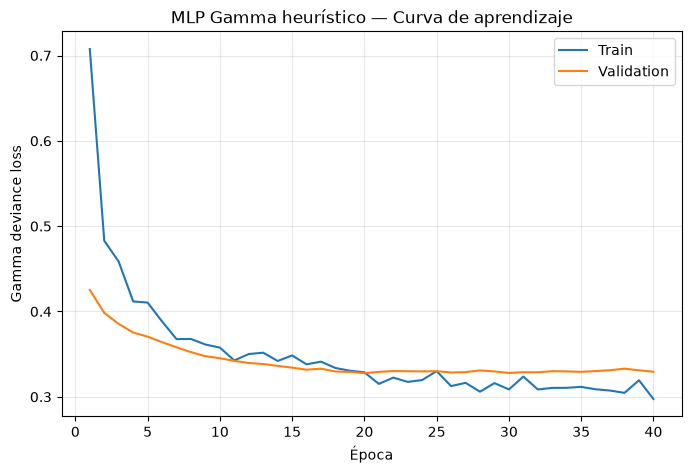

In [89]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_sev_df.index + 1,
    history_sev_df["loss"],
    label="Train"
)

plt.plot(
    history_sev_df.index + 1,
    history_sev_df["val_loss"],
    label="Validation"
)

plt.xlabel("Época")
plt.ylabel("Gamma deviance loss")
plt.title(
    "MLP Gamma heurístico — Curva de aprendizaje"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

La evolución del MAE muestra un patrón similar. La mayor parte de la mejora se
produce durante las primeras 15-20 épocas y posteriormente ambas curvas
presentan pequeñas oscilaciones alrededor de una región relativamente estable.

El mínimo del MAE no necesariamente coincide con el mínimo de Gamma deviance,
ya que ambas métricas penalizan los errores de manera diferente. La selección
del modelo se mantiene basada en Gamma deviance, que es el criterio definido
previamente para este problema.

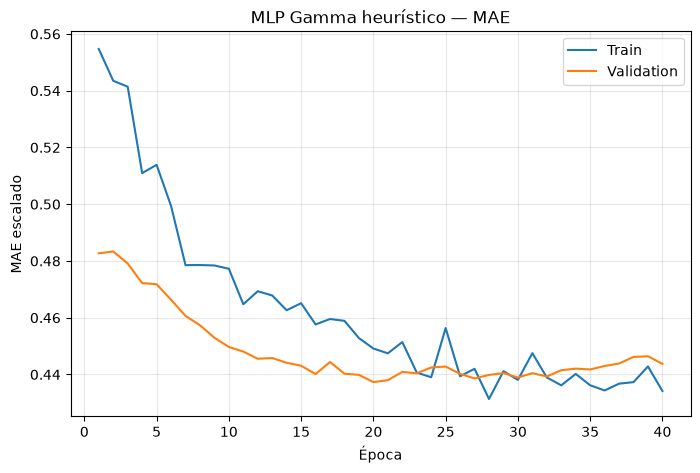

In [90]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_sev_df.index + 1,
    history_sev_df["mae"],
    label="Train"
)

plt.plot(
    history_sev_df.index + 1,
    history_sev_df["val_mae"],
    label="Validation"
)

plt.xlabel("Época")
plt.ylabel("MAE escalado")
plt.title(
    "MLP Gamma heurístico — MAE"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 4.11 Predicciones en escala original

Las predicciones permanecen estrictamente positivas gracias a la activación
Softplus de la capa de salida.

En test, la severidad media predicha es aproximadamente 13,033 frente a una
severidad observada media de 12,754, lo que equivale a una sobreestimación
agregada cercana al 2.2%.

La calibración global en media es, por tanto, razonablemente buena. Sin embargo,
la coincidencia de medias no implica necesariamente que el modelo recupere
correctamente las diferencias individuales de riesgo, por lo que posteriormente
se analiza también su desempeño contra la severidad esperada verdadera.

In [91]:
pred_train_sev_scaled_heur = (
    mlp_sev_heuristic
    .predict(
        X_sev_train,
        verbose=0
    )
    .ravel()
)

pred_val_sev_scaled_heur = (
    mlp_sev_heuristic
    .predict(
        X_sev_val,
        verbose=0
    )
    .ravel()
)

pred_test_sev_scaled_heur = (
    mlp_sev_heuristic
    .predict(
        X_sev_test,
        verbose=0
    )
    .ravel()
)

In [92]:
pred_train_sev_mlp_heur = (
    pred_train_sev_scaled_heur
    * SEVERITY_SCALE
)

pred_val_sev_mlp_heur = (
    pred_val_sev_scaled_heur
    * SEVERITY_SCALE
)

pred_test_sev_mlp_heur = (
    pred_test_sev_scaled_heur
    * SEVERITY_SCALE
)

In [93]:
print(
    f"Predicción mínima test: "
    f"{pred_test_sev_mlp_heur.min():,.2f}"
)

print(
    f"Predicción máxima test: "
    f"{pred_test_sev_mlp_heur.max():,.2f}"
)

print(
    f"Predicción media test: "
    f"{pred_test_sev_mlp_heur.mean():,.2f}"
)

print(
    f"Severidad observada media test: "
    f"{y_sev_test.mean():,.2f}"
)

Predicción mínima test: 6,704.88
Predicción máxima test: 23,287.63
Predicción media test: 13,032.54
Severidad observada media test: 12,753.53


### 4.12 Métricas 

Las métricas muestran un desempeño relativamente similar entre train y
validation, mientras que el error aumenta de forma más clara en el conjunto de
test.

El MAE pasa de aproximadamente 5,408 en train a 6,011 en test, mientras que el
RMSE aumenta de alrededor de 7,631 a 9,068.

La diferencia es especialmente visible en RMSE, métrica sensible a errores de
gran magnitud. Dado el reducido tamaño del conjunto de test (315 siniestros),
unas pocas realizaciones de severidad elevada pueden afectar considerablemente
esta métrica.

En conjunto, los resultados sugieren cierta pérdida de generalización, aunque
no un colapso del modelo fuera de muestra.

In [94]:
sev_train_metrics_heur = (
    regression_metrics(
        y_sev_train,
        pred_train_sev_mlp_heur
    )
)

sev_val_metrics_heur = (
    regression_metrics(
        y_sev_val,
        pred_val_sev_mlp_heur
    )
)

sev_test_metrics_heur = (
    regression_metrics(
        y_sev_test,
        pred_test_sev_mlp_heur
    )
)

In [95]:
pd.DataFrame(
    [
        sev_train_metrics_heur,
        sev_val_metrics_heur,
        sev_test_metrics_heur
    ],
    index=[
        "Train",
        "Validation",
        "Test"
    ]
)

,MAE,RMSE
Train,5408.131836,7630.970843
Validation,5526.269531,7339.331032
Test,6011.442383,9068.157917


*Gamma deviance*

La Gamma deviance aumenta progresivamente desde aproximadamente 0.287 en train
hasta 0.317 en validation y 0.337 en test.

Este patrón es consistente con una pérdida gradual de capacidad de
generalización al pasar de los datos utilizados para ajustar la red hacia
observaciones completamente externas.

La diferencia entre train y validation también coincide con la evidencia
observada en las curvas de aprendizaje: después de aproximadamente 20 épocas,
la red continúa ajustando el conjunto de entrenamiento sin mejorar de manera
equivalente su desempeño de validación.

In [96]:
sev_train_deviance_heur = (
    mean_gamma_deviance(
        y_sev_train,
        pred_train_sev_mlp_heur
    )
)

sev_val_deviance_heur = (
    mean_gamma_deviance(
        y_sev_val,
        pred_val_sev_mlp_heur
    )
)

sev_test_deviance_heur = (
    mean_gamma_deviance(
        y_sev_test,
        pred_test_sev_mlp_heur
    )
)

In [97]:
pd.DataFrame({
    "Gamma_deviance": [
        sev_train_deviance_heur,
        sev_val_deviance_heur,
        sev_test_deviance_heur
    ]
}, index=[
    "Train",
    "Validation",
    "Test"
])

,Gamma_deviance
Train,0.287487
Validation,0.317411
Test,0.336529


### 4.13 Oracle

La comparación con la severidad esperada verdadera muestra que la red aprende
una relación real entre las características de la póliza y la severidad, pero
su recuperación del DGP es menos precisa que la obtenida por los modelos
estadísticos y de Machine Learning analizados previamente.

El modelo alcanza un RMSE oracle cercano a 2,058 y una correlación de
aproximadamente 0.937.

La correlación elevada confirma que la red identifica parte importante del
ordenamiento relativo del riesgo. Sin embargo, sus errores respecto a la
esperanza condicional verdadera son sustancialmente mayores que los obtenidos
por GLM Gamma, XGBoost y Random Forest.

Esto sugiere que, con solamente 993 claims de entrenamiento, la flexibilidad
adicional de una red neuronal no se traduce automáticamente en una mejor
estimación de la función de severidad.

In [98]:
sev_oracle_metrics_heur = (
    regression_metrics(
        severity_true_test,
        pred_test_sev_mlp_heur
    )
)

sev_oracle_corr_heur = np.corrcoef(
    severity_true_test,
    pred_test_sev_mlp_heur
)[0, 1]

print(
    f"Oracle MAE: "
    f"{sev_oracle_metrics_heur['MAE']:,.2f}"
)

print(
    f"Oracle RMSE: "
    f"{sev_oracle_metrics_heur['RMSE']:,.2f}"
)

print(
    f"Oracle correlation: "
    f"{sev_oracle_corr_heur:.4f}"
)

Oracle MAE: 1,587.88
Oracle RMSE: 2,057.53
Oracle correlation: 0.9368


### 4.14 Optimización bayesiana del modelo de severidad

El modelo heurístico proporciona una arquitectura inicial para estimar la
severidad esperada, pero sus hiperparámetros se determinan mediante reglas
predefinidas y no mediante el desempeño observado en validation.

Se utilizará optimización bayesiana para investigar si una configuración
alternativa puede reducir la Gamma deviance de validación.

Debido al reducido tamaño de muestra disponible para severidad, el espacio de
búsqueda se restringe deliberadamente a arquitecturas compactas y niveles
moderados de regularización.

El conjunto de test permanecerá completamente aislado durante la búsqueda.

#### 4.14.1 Espacio de búsqueda

La búsqueda se limita a redes relativamente pequeñas debido al tamaño de la
muestra.

Se explorarán:

- entre 1 y 3 capas ocultas;
- entre 8 y 64 neuronas en la primera capa;
- arquitecturas decrecientes o de ancho constante;
- Dropout entre 0.10 y 0.40;
- regularización L2 entre $10^{-6}$ y $10^{-2}$;
- learning rate entre $10^{-4}$ y $2\times10^{-3}$.

No se incluyen arquitecturas considerablemente mayores porque el objetivo no es
maximizar capacidad indiscriminadamente, sino encontrar una complejidad
razonable para una muestra de aproximadamente mil observaciones.

#### 4.14.2 Constructor parametrizado

In [100]:
def build_gamma_mlp_tuned(hp):
    """
    Construye una MLP para severidad positiva.

    Los hiperparámetros son seleccionados por Keras Tuner
    y la red se entrena utilizando Gamma deviance.
    """

    # ---------------------------------------------------------
    # Arquitectura
    # ---------------------------------------------------------

    n_layers = hp.Int(
        "n_layers",
        min_value=1,
        max_value=3,
        step=1
    )

    first_units = hp.Choice(
        "first_units",
        values=[8, 16, 32, 64]
    )

    reduction = hp.Choice(
        "reduction",
        values=[0.5, 0.75, 1.0]
    )

    # ---------------------------------------------------------
    # Regularización
    # ---------------------------------------------------------

    dropout = hp.Float(
        "dropout",
        min_value=0.10,
        max_value=0.40,
        step=0.05
    )

    l2_value = hp.Float(
        "l2",
        min_value=1e-6,
        max_value=1e-2,
        sampling="log"
    )

    # ---------------------------------------------------------
    # Optimización
    # ---------------------------------------------------------

    learning_rate = hp.Float(
        "learning_rate",
        min_value=1e-4,
        max_value=2e-3,
        sampling="log"
    )

    # =========================================================
    # Construcción
    # =========================================================

    model = keras.Sequential(
        name="gamma_mlp_bayesian"
    )

    model.add(
        keras.layers.Input(
            shape=(n0_sev,)
        )
    )

    units = first_units

    for _ in range(n_layers):

        current_units = max(
            8,
            int(round(units))
        )

        model.add(
            keras.layers.Dense(
                current_units,
                activation="relu",
                kernel_regularizer=(
                    keras.regularizers.l2(
                        l2_value
                    )
                )
            )
        )

        model.add(
            keras.layers.Dropout(
                dropout
            )
        )

        units *= reduction

    # La severidad escalada tiene media cercana a 1.
    initial_output = np.log(
        np.exp(1.0) - 1.0
    )

    model.add(
        keras.layers.Dense(
            1,
            activation="softplus",
            bias_initializer=(
                keras.initializers.Constant(
                    initial_output
                )
            )
        )
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=gamma_deviance_loss,

        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

#### 4.14.3 Crear el tuner

In [104]:
import shutil

In [105]:
SEV_TUNER_DIR = Path(
    "../results/tuning/severity_bayesian"
)

if SEV_TUNER_DIR.exists():
    shutil.rmtree(
        SEV_TUNER_DIR
    )

In [103]:
keras.backend.clear_session()
set_reproducibility(SEED)

In [106]:
tuner_sev = kt.BayesianOptimization(
    hypermodel=build_gamma_mlp_tuned,

    objective=kt.Objective(
        "val_loss",
        direction="min"
    ),

    max_trials=15,

    executions_per_trial=1,

    seed=SEED,

    directory=str(
        SEV_TUNER_DIR
    ),

    project_name="gamma_mlp",

    overwrite=True
)

#### 4.14.4 Revisar el espacio

In [107]:
tuner_sev.search_space_summary()

Search space summary
Default search space size: 6
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
first_units (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32, 64], 'ordered': True}
reduction (Choice)
{'default': 0.5, 'conditions': [], 'values': [0.5, 0.75, 1.0], 'ordered': True}
dropout (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.05, 'sampling': 'linear'}
l2 (Float)
{'default': 1e-06, 'conditions': [], 'min_value': 1e-06, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.002, 'step': None, 'sampling': 'log'}


#### 4.14.5 Early Stopping durante HPO

In [108]:
tuning_early_stopping_sev = (
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=0
    )
)

In [109]:
SEV_TUNING_MAX_EPOCHS = 250

#### 4.14.6 Ejecutar búsqueda

Aunque el espacio permitía arquitecturas de hasta tres capas y 64 neuronas en
la primera capa, la mejor configuración encontrada resultó considerablemente
más pequeña.

La búsqueda seleccionó una sola capa oculta con 16 neuronas, indicando que, para
el tamaño de muestra disponible, una mayor profundidad no fue necesaria para
obtener el mejor desempeño de validación observado.

Este resultado es consistente con la decisión de restringir la búsqueda a
arquitecturas compactas: la flexibilidad adicional de redes más grandes no
produjo automáticamente una menor Gamma deviance.

In [110]:
set_reproducibility(SEED)

start = time.perf_counter()

tuner_sev.search(
    X_sev_train,
    y_sev_train_scaled,

    validation_data=(
        X_sev_val,
        y_sev_val_scaled
    ),

    epochs=SEV_TUNING_MAX_EPOCHS,

    batch_size=32,

    callbacks=[
        tuning_early_stopping_sev
    ],

    verbose=1
)

sev_bayesian_search_time = (
    time.perf_counter()
    - start
)

print(
    "\nTiempo total de Bayesian Optimization: "
    f"{sev_bayesian_search_time:.2f} segundos"
)

Trial 15 Complete [00h 00m 31s]
val_loss: 0.3203764259815216

Best val_loss So Far: 0.305791974067688
Total elapsed time: 00h 05m 16s

Tiempo total de Bayesian Optimization: 315.66 segundos


#### 4.14.7 Resultados

Los mejores trials se concentran principalmente en arquitecturas de baja
capacidad, con primeras capas de 8 o 16 neuronas.

El mejor trial obtuvo una pérdida de validación de aproximadamente 0.3058,
seguido por configuraciones cercanas a 0.3107 y 0.3109.

Aunque la mejor configuración presenta una ventaja visible, varias regiones del
espacio muestran desempeños relativamente próximos. Por ello, el resultado no
debe interpretarse como evidencia de que una combinación exacta de
hiperparámetros sea universalmente óptima, sino como la identificación de una
región prometedora del espacio de búsqueda.

In [111]:
tuner_sev.results_summary(
    num_trials=10
)

Results summary
Results in ..\results\tuning\severity_bayesian\gamma_mlp
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 05 summary
Hyperparameters:
n_layers: 1
first_units: 16
reduction: 1.0
dropout: 0.25
l2: 3.0354743289178576e-05
learning_rate: 0.0010956530832759268
Score: 0.305791974067688

Trial 03 summary
Hyperparameters:
n_layers: 1
first_units: 16
reduction: 1.0
dropout: 0.25
l2: 8.028474807082747e-05
learning_rate: 0.00034641316112625194
Score: 0.3106784224510193

Trial 06 summary
Hyperparameters:
n_layers: 3
first_units: 8
reduction: 0.5
dropout: 0.25
l2: 3.7921212101221703e-06
learning_rate: 0.00044209342856388133
Score: 0.3108747601509094

Trial 08 summary
Hyperparameters:
n_layers: 1
first_units: 8
reduction: 0.75
dropout: 0.4
l2: 0.00015388851689565532
learning_rate: 0.0009749736643141464
Score: 0.3129322826862335

Trial 14 summary
Hyperparameters:
n_layers: 2
first_units: 8
reduction: 1.0
dropout: 0.30000000000000004
l2: 0.00011998080392384018
l

In [112]:
best_hp_sev = (
    tuner_sev
    .get_best_hyperparameters(
        num_trials=1
    )[0]
)

**Regularización**

La optimización mantuvo un Dropout de 0.25, valor muy cercano al propuesto por
la heurística original.

En contraste, la penalización L2 disminuyó desde \(3\times10^{-4}\) hasta
aproximadamente \(3.0\times10^{-5}\), es decir, alrededor de un orden de
magnitud.

La configuración seleccionada combina por tanto una arquitectura más pequeña
con una penalización explícita sobre los pesos considerablemente menor.

Esto sugiere que el control de complejidad puede provenir principalmente del
tamaño reducido de la propia red, sin requerir una regularización L2 tan intensa.

**Learning rate**

El learning rate seleccionado fue aproximadamente $1.10\times10^{-3}$, muy
cercano al valor de $10^{-3}$ utilizado en la arquitectura heurística.

Por tanto, la mejora observada no parece provenir principalmente de una
modificación importante de la velocidad de aprendizaje, sino de la combinación
entre arquitectura y regularización.


In [113]:
print(
    "Mejores hiperparámetros:"
)

for name, value in (
    best_hp_sev.values.items()
):

    print(
        f"{name:<20}: {value}"
    )

Mejores hiperparámetros:
n_layers            : 1
first_units         : 16
reduction           : 1.0
dropout             : 0.25
l2                  : 3.0354743289178576e-05
learning_rate       : 0.0010956530832759268


#### 4.14.8 Reconstruir la arquitectura seleccionada

#### Arquitectura seleccionada

La arquitectura seleccionada mediante optimización bayesiana es:

$$
14 \rightarrow 16 \rightarrow 1.
$$

Es considerablemente más simple que la arquitectura heurística inicial:

$$
14 \rightarrow 28 \rightarrow 14 \rightarrow 1.
$$

El resultado muestra que, con aproximadamente mil observaciones de
entrenamiento, aumentar la profundidad y el número de parámetros no fue
necesario para mejorar el criterio de validación.

En este caso, una red más compacta produjo un mejor equilibrio entre capacidad
de aprendizaje y generalización.

In [114]:
best_n_layers_sev = (
    best_hp_sev.get(
        "n_layers"
    )
)

best_first_units_sev = (
    best_hp_sev.get(
        "first_units"
    )
)

best_reduction_sev = (
    best_hp_sev.get(
        "reduction"
    )
)

best_dropout_sev = (
    best_hp_sev.get(
        "dropout"
    )
)

best_l2_sev = (
    best_hp_sev.get(
        "l2"
    )
)

best_learning_rate_sev = (
    best_hp_sev.get(
        "learning_rate"
    )
)

In [115]:
best_architecture_sev = []

units = best_first_units_sev

for _ in range(
    best_n_layers_sev
):

    current_units = max(
        8,
        int(round(units))
    )

    best_architecture_sev.append(
        current_units
    )

    units *= best_reduction_sev

print(
    "Arquitectura encontrada:",
    " → ".join(
        map(
            str,
            best_architecture_sev
        )
    )
)

Arquitectura encontrada: 16


#### Heurística vs optimización bayesiana

La optimización bayesiana reduce la mejor pérdida de validación desde
aproximadamente 0.3277 hasta 0.3058, equivalente a una mejora relativa cercana
al 6.7%.

La ganancia predictiva requiere, sin embargo, un costo computacional
considerablemente mayor.

El entrenamiento de una única arquitectura heurística requirió alrededor de
5 segundos, mientras que la exploración de 15 configuraciones mediante
optimización bayesiana necesitó aproximadamente 316 segundos.

Por tanto, la búsqueda completa requiere alrededor de 60 veces más tiempo que
el entrenamiento del modelo heurístico individual.

Este costo corresponde al proceso de selección y no al costo de utilizar
posteriormente la arquitectura seleccionada.

#### Heurística vs optimización bayesiana

La optimización bayesiana reduce la mejor pérdida de validación desde
aproximadamente 0.3277 hasta 0.3058, equivalente a una mejora relativa cercana
al 6.7%.

La ganancia predictiva requiere, sin embargo, un costo computacional
considerablemente mayor.

El entrenamiento de una única arquitectura heurística requirió alrededor de
5 segundos, mientras que la exploración de 15 configuraciones mediante
optimización bayesiana necesitó aproximadamente 316 segundos.

Por tanto, la búsqueda completa requiere alrededor de 60 veces más tiempo que
el entrenamiento del modelo heurístico individual.

Este costo corresponde al proceso de selección y no al costo de utilizar
posteriormente la arquitectura seleccionada.

### 4.15 Estabilidad de la configuración seleccionada

La optimización bayesiana identifica una combinación de hiperparámetros
prometedora, pero el entrenamiento de una red neuronal sigue dependiendo de
elementos aleatorios como la inicialización de pesos, Dropout y el orden de los
mini-batches.

Para estudiar esta sensibilidad, la configuración seleccionada se entrena con
tres semillas distintas:

$$
42,\quad123,\quad2026.
$$

Estas ejecuciones no se utilizan para seleccionar una nueva arquitectura ni para
escoger retrospectivamente la semilla con mejor desempeño.

Su objetivo es cuantificar la variabilidad del proceso de entrenamiento antes de
realizar la evaluación final sobre test.

#### 4.15.1 Constructor fijo

In [116]:
def build_fixed_gamma_mlp(
    n0,
    architecture,
    dropout,
    l2_value,
    learning_rate
):
    """
    Construye una MLP Gamma utilizando una configuración
    previamente seleccionada.
    """

    model = keras.Sequential(
        name="gamma_mlp_selected"
    )

    model.add(
        keras.layers.Input(
            shape=(n0,)
        )
    )

    for units in architecture:

        model.add(
            keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=(
                    keras.regularizers.l2(
                        l2_value
                    )
                )
            )
        )

        model.add(
            keras.layers.Dropout(
                dropout
            )
        )

    # La severidad escalada tiene media aproximadamente igual a 1.
    initial_output = np.log(
        np.exp(1.0) - 1.0
    )

    model.add(
        keras.layers.Dense(
            1,
            activation="softplus",
            bias_initializer=(
                keras.initializers.Constant(
                    initial_output
                )
            )
        )
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=gamma_deviance_loss,

        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

#### 4.15.2 Ejecuciones con distintas semillas

In [117]:
SEVERITY_VALIDATION_SEEDS = [
    42,
    123,
    2026
]

severity_validation_runs = []

In [118]:
for seed in SEVERITY_VALIDATION_SEEDS:

    # ---------------------------------------------------------
    # Reproducibilidad independiente de cada ejecución
    # ---------------------------------------------------------
    keras.backend.clear_session()
    set_reproducibility(seed)

    # ---------------------------------------------------------
    # Construcción
    # ---------------------------------------------------------
    model_run = build_fixed_gamma_mlp(
        n0=n0_sev,
        architecture=best_architecture_sev,
        dropout=best_dropout_sev,
        l2_value=best_l2_sev,
        learning_rate=best_learning_rate_sev
    )

    # ---------------------------------------------------------
    # Early stopping
    # ---------------------------------------------------------
    early_stopping_run = (
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=0
        )
    )

    # ---------------------------------------------------------
    # Entrenamiento
    # ---------------------------------------------------------
    start = time.perf_counter()

    history_run = model_run.fit(
        X_sev_train,
        y_sev_train_scaled,

        validation_data=(
            X_sev_val,
            y_sev_val_scaled
        ),

        epochs=400,
        batch_size=32,

        callbacks=[
            early_stopping_run
        ],

        verbose=0
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    # ---------------------------------------------------------
    # Mejor época según val_loss
    # ---------------------------------------------------------
    val_losses = (
        history_run.history[
            "val_loss"
        ]
    )

    best_epoch = (
        np.argmin(val_losses)
        + 1
    )

    best_val_loss = (
        np.min(val_losses)
    )

    # ---------------------------------------------------------
    # Predicción validation en escala original
    # ---------------------------------------------------------
    pred_val_scaled = (
        model_run.predict(
            X_sev_val,
            verbose=0
        )
        .ravel()
    )

    pred_val_original = (
        pred_val_scaled
        * SEVERITY_SCALE
    )

    validation_gamma_deviance = (
        mean_gamma_deviance(
            y_sev_val,
            pred_val_original
        )
    )

    # ---------------------------------------------------------
    # Guardar resultados
    # ---------------------------------------------------------
    severity_validation_runs.append({
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "val_gamma_deviance": validation_gamma_deviance,
        "epochs_run": len(val_losses),
        "time_seconds": elapsed
    })

In [119]:
severity_validation_runs_df = pd.DataFrame(
    severity_validation_runs
)

severity_validation_runs_df

,seed,best_epoch,best_val_loss,val_gamma_deviance,epochs_run,time_seconds
0,42,37,0.314735,0.314234,57,7.510176
1,123,25,0.304491,0.304036,45,6.102433
2,2026,60,0.317751,0.317215,80,8.924937


In [120]:
severity_validation_runs_df[
    [
        "best_epoch",
        "best_val_loss",
        "val_gamma_deviance"
    ]
].agg(
    [
        "mean",
        "std",
        "min",
        "max"
    ]
)

,best_epoch,best_val_loss,val_gamma_deviance
mean,40.666667,0.312326,0.311829
std,17.785762,0.006950,0.006911
min,25.000000,0.304491,0.304036
max,60.000000,0.317751,0.317215


### 4.16 Modelo final de severidad

Las ejecuciones con múltiples semillas se utilizan únicamente para estudiar la
estabilidad del entrenamiento.

Para evitar seleccionar retrospectivamente una inicialización favorable, el
modelo oficial utiliza la semilla global del proyecto:

$$
SEED=42.
$$

A diferencia del procedimiento utilizado inicialmente para frecuencia, no se
realizará un refit posterior utilizando un número fijo de épocas.

El modelo conservará el split train/validation y utilizará Early Stopping con
`restore_best_weights=True`. De esta manera, el checkpoint final corresponde
directamente al mínimo observado en validation.

Una vez restaurados estos pesos, el conjunto de test se utiliza por primera vez
para evaluar el modelo.

#### 4.16.1 Entrenar modelo oficial

In [121]:
keras.backend.clear_session()
set_reproducibility(SEED)

mlp_sev_final = build_fixed_gamma_mlp(
    n0=n0_sev,
    architecture=best_architecture_sev,
    dropout=best_dropout_sev,
    l2_value=best_l2_sev,
    learning_rate=best_learning_rate_sev
)

mlp_sev_final.summary()

Model: "gamma_mlp_selected"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

In [122]:
sev_final_n_params = (
    mlp_sev_final.count_params()
)

print(
    f"Parámetros entrenables: "
    f"{sev_final_n_params:,}"
)

Parámetros entrenables: 257


#### 4.16.2 Entrenamiento

In [123]:
final_early_stopping_sev = (
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    )
)

In [124]:
set_reproducibility(SEED)

start = time.perf_counter()

history_sev_final = (
    mlp_sev_final.fit(
        X_sev_train,
        y_sev_train_scaled,

        validation_data=(
            X_sev_val,
            y_sev_val_scaled
        ),

        epochs=400,
        batch_size=32,

        callbacks=[
            final_early_stopping_sev
        ],

        verbose=0
    )
)

sev_final_train_time = (
    time.perf_counter()
    - start
)

Epoch 57: early stopping
Restoring model weights from the end of the best epoch: 37.


In [125]:
final_sev_val_losses = (
    history_sev_final.history[
        "val_loss"
    ]
)

final_sev_best_epoch = (
    np.argmin(
        final_sev_val_losses
    )
    + 1
)

final_sev_best_val_loss = (
    np.min(
        final_sev_val_losses
    )
)

print(
    f"Tiempo final: "
    f"{sev_final_train_time:.2f} segundos"
)

print(
    f"Épocas ejecutadas: "
    f"{len(final_sev_val_losses)}"
)

print(
    f"Mejor época: "
    f"{final_sev_best_epoch}"
)

print(
    f"Mejor val_loss: "
    f"{final_sev_best_val_loss:.6f}"
)

Tiempo final: 7.71 segundos
Épocas ejecutadas: 57
Mejor época: 37
Mejor val_loss: 0.314735


### 4.17 Evaluación final de severidad

In [126]:
pred_train_sev_scaled_final = (
    mlp_sev_final
    .predict(
        X_sev_train,
        verbose=0
    )
    .ravel()
)

pred_val_sev_scaled_final = (
    mlp_sev_final
    .predict(
        X_sev_val,
        verbose=0
    )
    .ravel()
)

pred_test_sev_scaled_final = (
    mlp_sev_final
    .predict(
        X_sev_test,
        verbose=0
    )
    .ravel()
)

In [127]:
pred_train_sev_mlp_final = (
    pred_train_sev_scaled_final
    * SEVERITY_SCALE
)

pred_val_sev_mlp_final = (
    pred_val_sev_scaled_final
    * SEVERITY_SCALE
)

pred_test_sev_mlp_final = (
    pred_test_sev_scaled_final
    * SEVERITY_SCALE
)

#### 4.17.1 calibración básica

In [128]:
print(
    f"Predicción mínima test: "
    f"{pred_test_sev_mlp_final.min():,.2f}"
)

print(
    f"Predicción máxima test: "
    f"{pred_test_sev_mlp_final.max():,.2f}"
)

print(
    f"Predicción media test: "
    f"{pred_test_sev_mlp_final.mean():,.2f}"
)

print(
    f"Severidad observada media test: "
    f"{y_sev_test.mean():,.2f}"
)

Predicción mínima test: 5,392.73
Predicción máxima test: 24,348.00
Predicción media test: 12,836.51
Severidad observada media test: 12,753.53


In [129]:
severity_mean_bias_pct = (
    (
        pred_test_sev_mlp_final.mean()
        / y_sev_test.mean()
    )
    - 1
) * 100

print(
    f"Diferencia media relativa: "
    f"{severity_mean_bias_pct:.2f}%"
)

Diferencia media relativa: 0.65%


#### 4.17.2 Métricas observables

In [130]:
sev_final_train_metrics = (
    regression_metrics(
        y_sev_train,
        pred_train_sev_mlp_final
    )
)

sev_final_val_metrics = (
    regression_metrics(
        y_sev_val,
        pred_val_sev_mlp_final
    )
)

sev_final_test_metrics = (
    regression_metrics(
        y_sev_test,
        pred_test_sev_mlp_final
    )
)

In [131]:
pd.DataFrame(
    [
        sev_final_train_metrics,
        sev_final_val_metrics,
        sev_final_test_metrics
    ],
    index=[
        "Train",
        "Validation",
        "Test"
    ]
)

,MAE,RMSE
Train,5235.874023,7507.346535
Validation,5481.685059,7426.214917
Test,5820.470703,8962.862043


#### 4.17.3 Gamma deviance

In [132]:
sev_final_train_deviance = (
    mean_gamma_deviance(
        y_sev_train,
        pred_train_sev_mlp_final
    )
)

sev_final_val_deviance = (
    mean_gamma_deviance(
        y_sev_val,
        pred_val_sev_mlp_final
    )
)

sev_final_test_deviance = (
    mean_gamma_deviance(
        y_sev_test,
        pred_test_sev_mlp_final
    )
)

In [133]:
pd.DataFrame({
    "Gamma_deviance": [
        sev_final_train_deviance,
        sev_final_val_deviance,
        sev_final_test_deviance
    ]
}, index=[
    "Train",
    "Validation",
    "Test"
])

,Gamma_deviance
Train,0.274791
Validation,0.314234
Test,0.322431


#### 4.17.4 Oracle

In [134]:
sev_final_oracle_metrics = (
    regression_metrics(
        severity_true_test,
        pred_test_sev_mlp_final
    )
)

sev_final_oracle_corr = np.corrcoef(
    severity_true_test,
    pred_test_sev_mlp_final
)[0, 1]

In [135]:
print(
    f"Oracle MAE: "
    f"{sev_final_oracle_metrics['MAE']:,.2f}"
)

print(
    f"Oracle RMSE: "
    f"{sev_final_oracle_metrics['RMSE']:,.2f}"
)

print(
    f"Oracle correlation: "
    f"{sev_final_oracle_corr:.4f}"
)

Oracle MAE: 1,159.05
Oracle RMSE: 1,643.35
Oracle correlation: 0.9503


### 4.18 Comparación entre redes de severidad

In [136]:
severity_dl_comparison = pd.DataFrame({
    "Modelo": [
        "MLP heurístico",
        "MLP bayesiano"
    ],

    "MAE test": [
        sev_test_metrics_heur["MAE"],
        sev_final_test_metrics["MAE"]
    ],

    "RMSE test": [
        sev_test_metrics_heur["RMSE"],
        sev_final_test_metrics["RMSE"]
    ],

    "Gamma deviance": [
        sev_test_deviance_heur,
        sev_final_test_deviance
    ],

    "Oracle MAE": [
        sev_oracle_metrics_heur["MAE"],
        sev_final_oracle_metrics["MAE"]
    ],

    "Oracle RMSE": [
        sev_oracle_metrics_heur["RMSE"],
        sev_final_oracle_metrics["RMSE"]
    ],

    "Oracle correlation": [
        sev_oracle_corr_heur,
        sev_final_oracle_corr
    ]
})

severity_dl_comparison

,Modelo,MAE test,RMSE test,Gamma deviance,Oracle MAE,Oracle RMSE,Oracle correlation
0,MLP heurístico,6011.442383,9068.157917,0.336529,1587.884155,2057.525820,0.936759
1,MLP bayesiano,5820.470703,8962.862043,0.322431,1159.052490,1643.348563,0.950288
